## Table of Contents
1. [Introduction](#1.-introduction)

2. [Organize Imports](#2.-organize-imports)

3. [Data Preprocessing](#3.-data-preprocessing)

    3.1 [Load Data](#3.1-load-data)

    3.2 [Analyze Duplicate Rows](#3.2-analyze-duplicate-rows)

    3.3 [Drop Duplicate Rows](#3.3-drop-duplicate-rows)

    3.4 [Analyze Missing Values](#3.4-analyze-missing-values)

    3.5 [Handle Missing Values](#3.5-handle-missing-values)

    3.6 [Clean up Redundant GENRE Columns](#3.6-clean-up-redundant-genre-columns)

    3.7 [Clean FIRST_WEEK (Date Column)](#3.7-clean-first_week-(date-column))

4. [Data Exploration](#4.-data-exploration)

    4.1 [Compute Statistics](#4.1-compute-statistics)

    4.2 [Analyze Distribution](#4.2-analyze-distribution)

    4.3 [Boxplot Numeric Variables](#4.3-boxplot-numeric-variables)

    4.4 [Treat Outliers](#4.4-treat-outliers)

    4.5 [Check for Multicollinearity](#4.5-check-for-multicollinearity)

    4.6 [Analyze Temporal Audio Preferences](#4.6-analyze-temporal-audio-preferences)

    4.7 [Cleanup and Consolidate Genres](#4.7-cleanup-and-consolidate-genres)

5. [Feature Engineering](#5.-feature-engineering)

    5.1 [Transform Key Skewed Variables](#5.1-transform-key-skewed-variables)

    5.2 [One-Hot Encode Categorical Variables](#5.2-one-hot-encode-categorical-variables)

    5.3 [Create HAS_PLAYLIST Dummy](#5.3-create-has_playlist-dummy)

6. [Initial Feature Selection](#6.-initial-feature-selection)

    6.1 [Drop Irrelevant / High-Cardinality Columns](#6.1-drop-irrelevant-/-high-cardinality-columns)

    6.2 [Assess Target Leakage](#6.2-assess-target-leakage)

    6.3 [Assign Feature Importance Using Shallow Decision Tree](#6.3-assign-feature-importance-using-shallow-decision-tree)

7. [Predictive Modeling](#7.-predictive-modeling)

    7.1 [Model Decision Tree Classifier](#7.1-model-decision-tree-classifier)

    7.2 [Summarize Decision Tree Model and Insights](#7.2-summarize-decision-tree-model-and-insights)

    7.3 [Model Logistic Regression](#7.3-model-logistic-regression)

    7.4 [Summarize Logistic Regression Model and Insights](#7.4-summarize-logistic-regression-model-and-insights)

8. [Conclusion](#8.-conclusion)

### 1. Introduction

This notebook presents a data-driven workflow to predict the commercial success of music tracks using audio features, release metadata, and historical performance indicators. The primary aim is to identify features that correlate with higher streaming and chart performance and to build predictive models that can inform A&R decisions, marketing prioritization, and resource allocation.

TODO: Standardize for LR. Not needed for DT.

### 2. Organize Imports

### 3. Data Preprocessing

In [1]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import mstats
from sklearn.feature_selection import mutual_info_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
from sklearn.tree import export_graphviz
import graphviz
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import textwrap
from sklearn.metrics import f1_score
from sklearn.metrics import balanced_accuracy_score
import statsmodels.api as sm
from imblearn.over_sampling import SMOTE

##### 3.1 Load Data

In [2]:
ms = pd.read_csv("../data/in/media-success.csv")
print(ms.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29488 entries, 0 to 29487
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   HIT                     29488 non-null  int64  
 1   SONG                    29488 non-null  object 
 2   ARTIST                  29487 non-null  object 
 3   PEAK_POSITION           29488 non-null  int64  
 4   FIRST_WEEK              29488 non-null  object 
 5   WEEKS_ON_CHART          29488 non-null  int64  
 6   SONG_DISPLAY            29488 non-null  object 
 7   ARTIST_DISPLAY          29488 non-null  object 
 8   DEBUT_RANK              29488 non-null  int64  
 9   DANCEABILITY            24419 non-null  float64
 10  ENERGY                  24419 non-null  float64
 11  LOUDNESS                24419 non-null  float64
 12  VALENCE                 24419 non-null  float64
 13  TEMPO                   24419 non-null  float64
 14  ACOUSTICNESS            24419 non-null

##### 3.2 Analyze Duplicate Rows

In [3]:
# Number of duplicate rows before cleaning up
print(f"Number of duplicate rows before cleaning up: {ms.duplicated().sum()}")

# View duplicate rows
duplicates = ms[ms.duplicated(keep=False)]
duplicates.head(10)

Number of duplicate rows before cleaning up: 78


,HIT,SONG,ARTIST,PEAK_POSITION,FIRST_WEEK,WEEKS_ON_CHART,SONG_DISPLAY,ARTIST_DISPLAY,DEBUT_RANK,DANCEABILITY,...,TRACK_NAME,TRACK_ARTIST,PLAYLIST_GENRE,PLAYLIST_SUBGENRE,SPOTIFY_POPULARITY,DURATION,GENRE,SENTIMENT_POLARITY,SENTIMENT_SUBJECTIVITY,MENTIONS
80,0,24 7,meek mill featuring ella mai,54,12/15/18,19,24/7,Meek Mill Featuring Ella Mai,54,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,hip hop,0.147840,0.102200,2515
81,0,24 7,meek mill featuring ella mai,54,12/15/18,19,24/7,Meek Mill Featuring Ella Mai,54,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,hip hop,0.147840,0.102200,2515
542,0,act up,city girls,26,3/16/19,21,Act Up,City Girls,77,0.938,...,Act Up,City Girls,r&b,hip pop,78.0,158332.0,r&b,0.207690,0.180400,7175
543,0,act up,city girls,26,3/16/19,21,Act Up,City Girls,77,0.938,...,Act Up,City Girls,r&b,hip pop,78.0,158332.0,r&b,0.207690,0.180400,7175
853,1,all i want for christmas is you,mariah carey,1,1/8/00,43,All I Want For Christmas Is You,Mariah Carey,83,0.335,...,All I Want for Christmas Is You,Mariah Carey,r&b,neo soul,90.0,241107.0,r&b,0.203641,0.269310,54487
854,1,all i want for christmas is you,mariah carey,1,1/8/00,43,All I Want For Christmas Is You,Mariah Carey,83,0.335,...,All I Want for Christmas Is You,Mariah Carey,r&b,neo soul,90.0,241107.0,r&b,0.203641,0.269310,54487
938,0,all the good girls go to hell,billie eilish,46,4/13/19,7,All The Good Girls Go To Hell,Billie Eilish,46,0.726,...,all the good girls go to hell,Billie Eilish,pop,indie poptimism,86.0,168840.0,pop,0.149560,0.279162,80731
939,0,all the good girls go to hell,billie eilish,46,4/13/19,7,All The Good Girls Go To Hell,Billie Eilish,46,0.726,...,all the good girls go to hell,Billie Eilish,pop,indie poptimism,86.0,168840.0,pop,0.149560,0.279162,80731
1887,0,bad bad bad,young thug featuring lil baby,32,8/31/19,9,Bad Bad Bad,Young Thug Featuring Lil Baby,32,0.974,...,Bad Bad Bad (feat. Lil Baby),Young Thug,rap,hip hop,81.0,149040.0,rap,-0.863183,0.537667,4974
1888,0,bad bad bad,young thug featuring lil baby,32,8/31/19,9,Bad Bad Bad,Young Thug Featuring Lil Baby,32,0.974,...,Bad Bad Bad (feat. Lil Baby),Young Thug,rap,hip hop,81.0,149040.0,rap,-0.863183,0.537667,4974


##### 3.3 Drop Duplicate Rows

In [4]:
before = ms.shape[0]

# Drop duplicate rows
ms = ms.drop_duplicates().reset_index(drop=True)

# Number of duplicate rows after cleaning up
print(f"Number of duplicate rows after cleaning up: {ms.duplicated().sum()}")

# View number of rows removed
print(f"Number of rows removed: {before - ms.shape[0]}")

Number of duplicate rows after cleaning up: 0
Number of rows removed: 78


##### 3.4 Analyze Missing Values

In [5]:
# Null value analysis
print(f"Null counts:\n{ms.isnull().sum().sort_values(ascending=False)}")
print(f"\n\nPercentage of missing values per column:\n{ms.isnull().mean().sort_values(ascending=False) * 100}")

Null counts:
TRACK_NAME                25941
TRACK_ARTIST              25941
PLAYLIST_GENRE            25941
PLAYLIST_SUBGENRE         25941
LIVENESS                   5061
INSTRUMENTALNESS           5061
SPEECHINESS                5061
TEMPO                      5061
VALENCE                    5061
LOUDNESS                   5061
ACOUSTICNESS               5061
DANCEABILITY               5061
ENERGY                     5061
SPOTIFY_POPULARITY         5001
DURATION                   5001
GENRE                      4098
SPOTIFY_GENRE              1596
ARTIST                        1
SENTIMENT_POLARITY            0
SENTIMENT_SUBJECTIVITY        0
HIT                           0
SONG                          0
DEBUT_RANK                    0
ARTIST_DISPLAY                0
SONG_DISPLAY                  0
WEEKS_ON_CHART                0
FIRST_WEEK                    0
PEAK_POSITION                 0
MENTIONS                      0
dtype: int64


Percentage of missing values per column:
TRA

##### 3.5 Handle Missing Values

In [6]:
# Drop high-missing columns (only two)
# Keep playlist columns for later feature engineering.
ms = ms.drop(columns=["TRACK_NAME", "TRACK_ARTIST"])


# Median imputation for numeric columns
numeric_cols = [
    "DANCEABILITY", "ENERGY", "LOUDNESS", "VALENCE", "TEMPO",
    "ACOUSTICNESS", "SPEECHINESS", "INSTRUMENTALNESS", "LIVENESS",
    "SPOTIFY_POPULARITY", "DURATION"
]

for col in numeric_cols:
    ms[col] = ms[col].fillna(ms[col].median())


# GENRE imputation with "Unknown"
ms["GENRE"] = ms["GENRE"].fillna("Unknown")


# Fill missing ARTIST value
ms["ARTIST"] = ms["ARTIST"].fillna("Unknown")


# Verify remaining nulls
ms.isnull().sum()

HIT                           0
SONG                          0
ARTIST                        0
PEAK_POSITION                 0
FIRST_WEEK                    0
WEEKS_ON_CHART                0
SONG_DISPLAY                  0
ARTIST_DISPLAY                0
DEBUT_RANK                    0
DANCEABILITY                  0
ENERGY                        0
LOUDNESS                      0
VALENCE                       0
TEMPO                         0
ACOUSTICNESS                  0
SPEECHINESS                   0
INSTRUMENTALNESS              0
LIVENESS                      0
SPOTIFY_GENRE              1596
PLAYLIST_GENRE            25941
PLAYLIST_SUBGENRE         25941
SPOTIFY_POPULARITY            0
DURATION                      0
GENRE                         0
SENTIMENT_POLARITY            0
SENTIMENT_SUBJECTIVITY        0
MENTIONS                      0
dtype: int64

##### 3.6 Clean up Redundant GENRE Columns

In [7]:
sg = ms["SPOTIFY_GENRE"]
genre = ms["GENRE"]
diff_values = ( sg.notna() & genre.notna() & (sg != genre) )
missing_one_side_genre = ( (sg.notna() & genre.isna()) )
missing_one_side_sg = ( (sg.isna() & genre.notna()) )

print("Total SG count:", sg.count())
print("Total GENRE count:", genre.count())
print("Different non-missing values:", diff_values.sum())
print("GENRE missing and SG valid:", missing_one_side_genre.sum())
print("SG missing and GENRE valid:", missing_one_side_sg.sum())

delta = ms[ (ms["GENRE"] == "Unknown") & (ms["SPOTIFY_GENRE"].notna()) ]
print(f"Length of delta: {len(delta)}")
print(delta["SPOTIFY_GENRE"].value_counts().head())

# Convert SPOTIFY_GENRE into lists and extract first tag
def get_first_spotify_tag(x):
    if pd.isna(x):
        return None
    try:
        # Convert stringified list -> list
        if isinstance(x, str):
            lst = ast.literal_eval(x)
        else:
            lst = x
        if not lst:
            return None
        return lst[0]  # first item
    except:
        return None

ms["FIRST_SPOTIFY_GENRE"] = ms["SPOTIFY_GENRE"].apply(get_first_spotify_tag)

# Show distributions
print(f"\n\nDistribution of SPOTIFY_GENRE: \n{ms['FIRST_SPOTIFY_GENRE'].value_counts(dropna=False).head(20)}")
print(f"\n\nDistribution of GENRE: \n{ms['GENRE'].value_counts(dropna=False).head(20)}")

Total SG count: 27814
Total GENRE count: 29410
Different non-missing values: 27814
GENRE missing and SG valid: 0
SG missing and GENRE valid: 1596
Length of delta: 2510
SPOTIFY_GENRE
[]    2510
Name: count, dtype: int64


Distribution of SPOTIFY_GENRE: 
FIRST_SPOTIFY_GENRE
None                    4150
adult standards         3713
album rock              2316
dance pop               2225
contemporary country    1378
brill building pop      1032
classic soul            1030
atl hip hop              525
disco                    395
bubblegum pop            385
pop                      358
alternative metal        348
hip hop                  313
funk                     299
dance rock               279
east coast hip hop       248
boy band                 236
country                  215
alternative rock         206
glee club                205
Name: count, dtype: int64


Distribution of GENRE: 
GENRE
Unknown                 4098
adult standards         3641
album rock              1849
da

`SPOTIFY_GENRE` contains more granular genre information compared to GENRE, particularly multi-genre tags. Also, it does not have a valid value for records where GENRE is unknown. Hence, we will drop that column.

In [8]:
# Drop helper column
if "FIRST_SPOTIFY_GENRE" in ms.columns:
    ms = ms.drop(columns=["FIRST_SPOTIFY_GENRE"])

# Drop raw Spotify genre column
if "SPOTIFY_GENRE" in ms.columns:
    ms = ms.drop(columns=["SPOTIFY_GENRE"])

# Confirm columns removed
print(ms.columns)
print(ms.shape)

Index(['HIT', 'SONG', 'ARTIST', 'PEAK_POSITION', 'FIRST_WEEK',
       'WEEKS_ON_CHART', 'SONG_DISPLAY', 'ARTIST_DISPLAY', 'DEBUT_RANK',
       'DANCEABILITY', 'ENERGY', 'LOUDNESS', 'VALENCE', 'TEMPO',
       'ACOUSTICNESS', 'SPEECHINESS', 'INSTRUMENTALNESS', 'LIVENESS',
       'PLAYLIST_GENRE', 'PLAYLIST_SUBGENRE', 'SPOTIFY_POPULARITY', 'DURATION',
       'GENRE', 'SENTIMENT_POLARITY', 'SENTIMENT_SUBJECTIVITY', 'MENTIONS'],
      dtype='object')
(29410, 26)


##### 3.7 Clean FIRST_WEEK (Date Column)

In [9]:
ms["FIRST_WEEK"] = pd.to_datetime(
    ms["FIRST_WEEK"],
    format="%m/%d/%y",
    errors="coerce"
)

# Check results
ms["FIRST_WEEK"].head(), ms["FIRST_WEEK"].isna().sum()

(0   2014-08-09
 1   2002-10-26
 2   2001-10-20
 3   1978-01-14
 4   2011-06-11
 Name: FIRST_WEEK, dtype: datetime64[ns],
 np.int64(0))

### 4. Data Exploration

##### 4.1 Compute Statistics

In [10]:
if (ms["SPOTIFY_POPULARITY"] % 1 == 0).all():
    ms["SPOTIFY_POPULARITY"] = ms["SPOTIFY_POPULARITY"].astype("int64")

# Describe numeric summary statistics
ms.drop(columns=["HIT"]).describe(include="number", exclude="datetime")

,PEAK_POSITION,WEEKS_ON_CHART,DEBUT_RANK,DANCEABILITY,ENERGY,LOUDNESS,VALENCE,TEMPO,ACOUSTICNESS,SPEECHINESS,INSTRUMENTALNESS,LIVENESS,SPOTIFY_POPULARITY,DURATION,SENTIMENT_POLARITY,SENTIMENT_SUBJECTIVITY,MENTIONS
count,29410.000000,29410.000000,29410.000000,29410.000000,29410.000000,29410.000000,29410.000000,29410.000000,29410.000000,29410.000000,29410.000000,29410.000000,29410.000000,2.941000e+04,29410.000000,29410.000000,29410.000000
mean,46.637130,11.181877,80.426522,0.601318,0.620999,-8.589592,0.605488,120.054431,0.277134,0.067949,0.026948,0.181617,40.461102,2.199240e+05,0.140350,0.251423,16416.510847
std,30.554977,8.302519,19.039162,0.139304,0.181263,3.280263,0.217193,25.523908,0.259565,0.076509,0.124624,0.146630,20.423374,6.185888e+04,0.228662,0.095086,29719.841312
min,1.000000,1.000000,1.000000,0.000000,0.000581,-28.030000,0.000000,0.000000,0.000003,0.000000,0.000000,0.009670,0.000000,2.968800e+04,-0.918600,0.000000,0.000000
25%,18.000000,5.000000,74.000000,0.525000,0.512000,-10.395750,0.464000,103.239750,0.066600,0.033600,0.000000,0.098800,26.000000,1.838832e+05,0.027106,0.205864,1863.000000
50%,46.000000,10.000000,86.000000,0.608000,0.634000,-8.210000,0.622000,118.921000,0.194000,0.041300,0.000005,0.131000,42.000000,2.150930e+05,0.139827,0.246773,6006.000000
75%,73.000000,16.000000,94.000000,0.685750,0.745000,-6.325000,0.765000,131.787000,0.425000,0.058700,0.000158,0.213000,55.000000,2.440660e+05,0.251300,0.297575,18797.000000
max,100.000000,87.000000,100.000000,0.988000,0.997000,2.291000,0.991000,241.009000,0.991000,0.951000,0.982000,0.999000,100.000000,3.079157e+06,0.940550,0.796000,236713.000000


In [11]:
# Describe categorical summary statistics
ms.describe(include='object')

,SONG,ARTIST,SONG_DISPLAY,ARTIST_DISPLAY,PLAYLIST_GENRE,PLAYLIST_SUBGENRE,GENRE
count,29410,29410,29410,29410,3469,3469,29410
unique,23552,9990,24334,10054,6,23,652
top,hold on,glee cast,Hold On,Glee Cast,rock,post-teen pop,Unknown
freq,18,182,17,182,1006,394,4098


In [12]:
# Describe datetime summary statistics
ms.describe(include='datetime')

,FIRST_WEEK
count,29410
mean,2011-01-25 20:34:59.530771968
min,1969-01-04 00:00:00
25%,1983-04-02 00:00:00
50%,2003-12-30 12:00:00
75%,2020-12-26 00:00:00
max,2068-12-28 00:00:00


##### 4.2 Analyze Distribution

In [13]:
print(f"Total columns: {ms.shape[1]}.")

numeric_cols = [c for c in ms.select_dtypes(include=["int64", "float64"]).columns if c != "HIT"]
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")

non_numeric_cols = [c for c in ms.select_dtypes(include=["object"]).columns if c != "HIT"]
print(f"Non-numeric columns ({len(non_numeric_cols)}): {non_numeric_cols}")

other_cols = [c for c in ms.columns if c not in numeric_cols + non_numeric_cols + ["HIT"]]
print(f"{ms[other_cols].to_numpy().dtype} ({len(other_cols)}): {other_cols}")

print(f"Focal dependent variable {ms['HIT'].to_numpy().dtype} (1): ['HIT']")

Total columns: 26.
Numeric columns (17): ['PEAK_POSITION', 'WEEKS_ON_CHART', 'DEBUT_RANK', 'DANCEABILITY', 'ENERGY', 'LOUDNESS', 'VALENCE', 'TEMPO', 'ACOUSTICNESS', 'SPEECHINESS', 'INSTRUMENTALNESS', 'LIVENESS', 'SPOTIFY_POPULARITY', 'DURATION', 'SENTIMENT_POLARITY', 'SENTIMENT_SUBJECTIVITY', 'MENTIONS']
Non-numeric columns (7): ['SONG', 'ARTIST', 'SONG_DISPLAY', 'ARTIST_DISPLAY', 'PLAYLIST_GENRE', 'PLAYLIST_SUBGENRE', 'GENRE']
datetime64[ns] (1): ['FIRST_WEEK']
Focal dependent variable int64 (1): ['HIT']


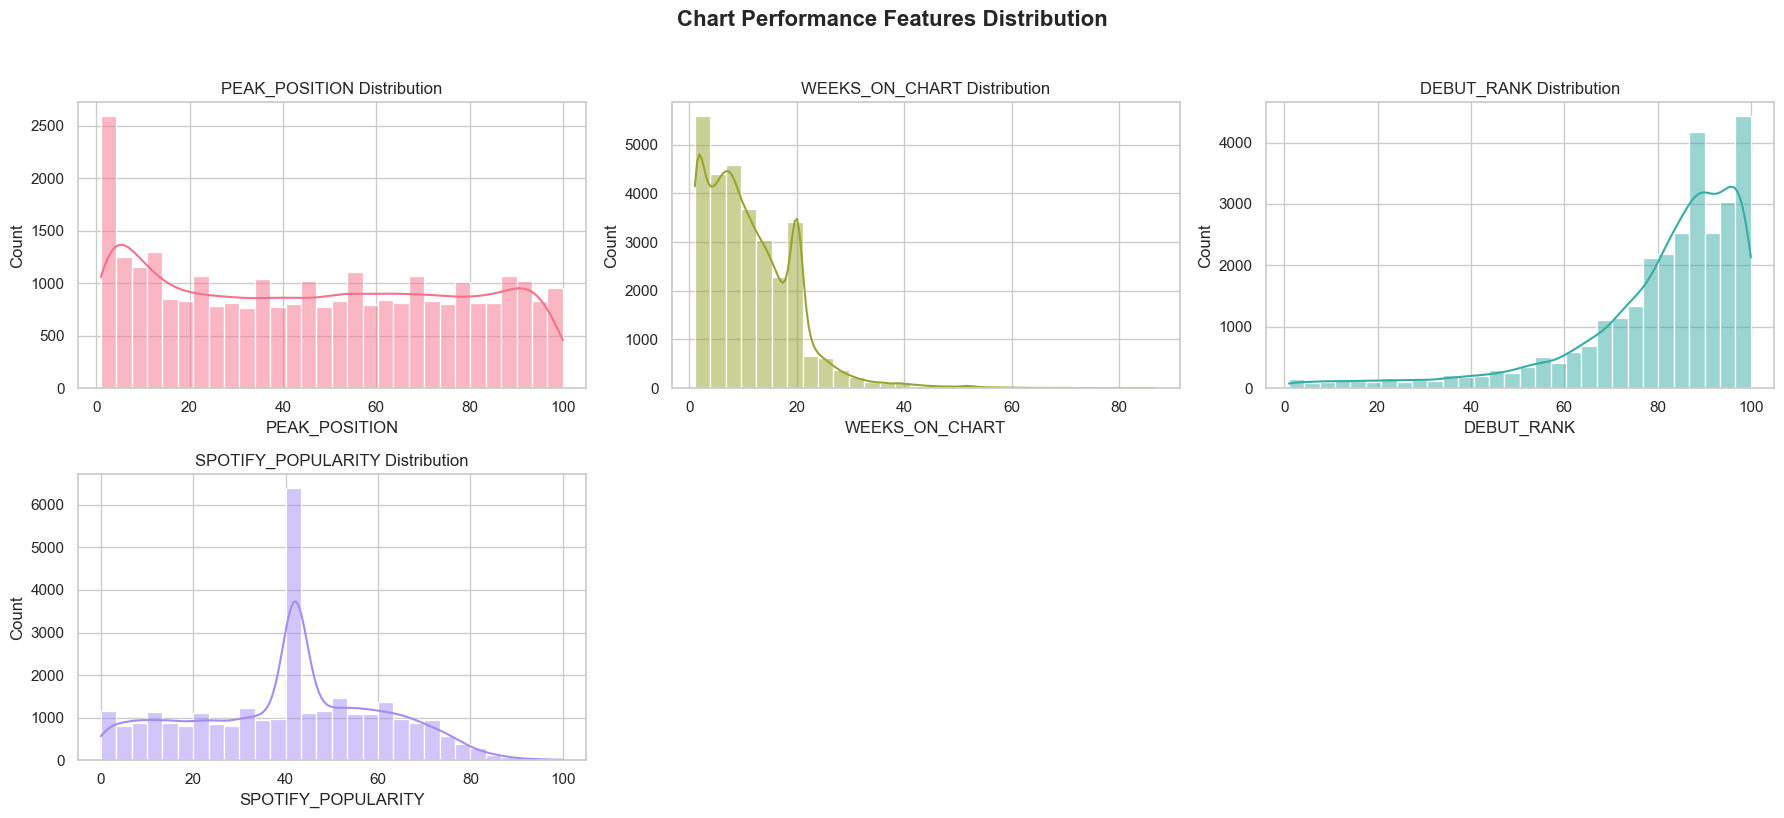

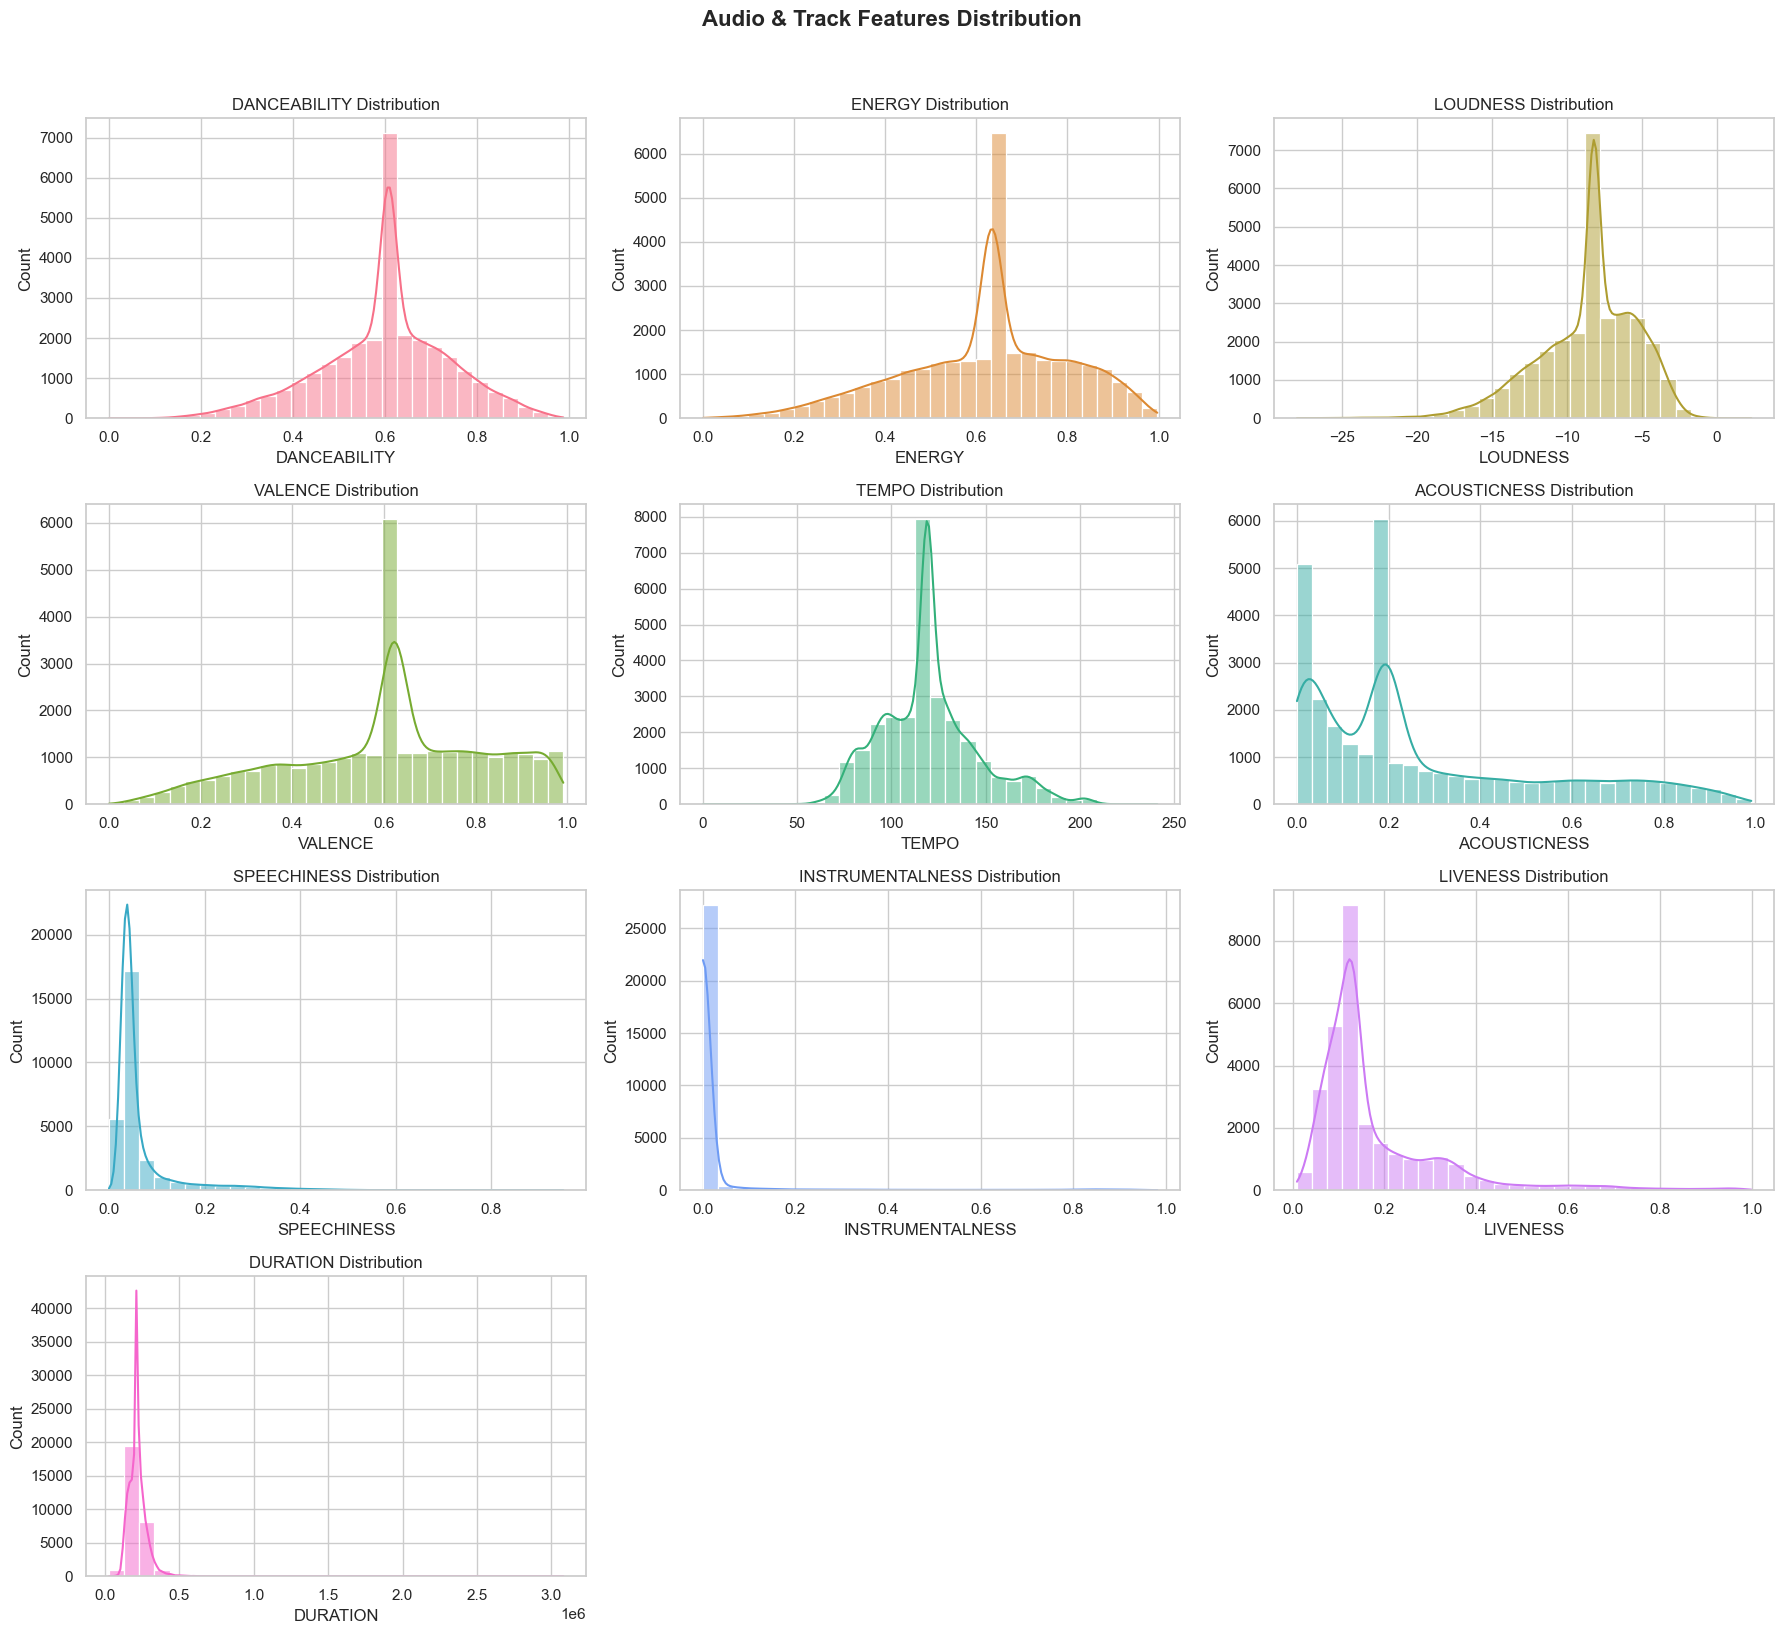

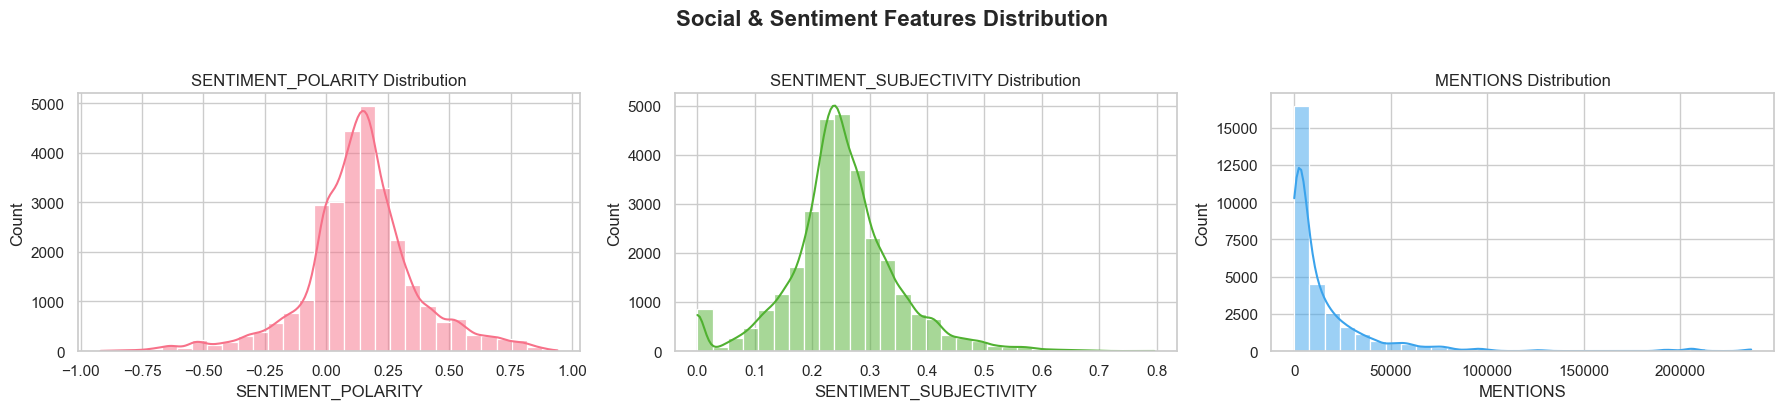

In [14]:
sns.set_theme(style="whitegrid")

# --- Buckets ---
chart_performance = [
    "PEAK_POSITION", "WEEKS_ON_CHART", "DEBUT_RANK", "SPOTIFY_POPULARITY"
]

audio_track = [
    "DANCEABILITY", "ENERGY", "LOUDNESS", "VALENCE", "TEMPO",
    "ACOUSTICNESS", "SPEECHINESS", "INSTRUMENTALNESS",
    "LIVENESS", "DURATION"
]

social = [
    "SENTIMENT_POLARITY", "SENTIMENT_SUBJECTIVITY", "MENTIONS"
]

# Chart Performance Features
n_cols = 3
n_rows = int(np.ceil(len(chart_performance) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

colors = sns.color_palette("husl", len(chart_performance))

for idx, col in enumerate(chart_performance):
    sns.histplot(
        ms[col], bins=30, kde=True,
        ax=axes[idx], color=colors[idx]
    )
    axes[idx].set_title(f"{col} Distribution")

for j in range(idx + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Chart Performance Features Distribution", fontsize=16, weight="bold", y=1.02)
plt.tight_layout()
plt.show()


# Audio & Track Features
n_cols = 3
n_rows = int(np.ceil(len(audio_track) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

colors = sns.color_palette("husl", len(audio_track))

for idx, col in enumerate(audio_track):
    sns.histplot(
        ms[col], bins=30, kde=True,
        ax=axes[idx], color=colors[idx]
    )
    axes[idx].set_title(f"{col} Distribution")

for j in range(idx + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Audio & Track Features Distribution", fontsize=16, weight="bold", y=1.02)
plt.tight_layout()
plt.show()


# Social & Sentiment Features
n_cols = 3
n_rows = int(np.ceil(len(social) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

colors = sns.color_palette("husl", len(social))

for idx, col in enumerate(social):
    sns.histplot(
        ms[col], bins=30, kde=True,
        ax=axes[idx], color=colors[idx]
    )
    axes[idx].set_title(f"{col} Distribution")

for j in range(idx + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Social & Sentiment Features Distribution", fontsize=16, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

##### 4.3 Boxplot Numeric Variables

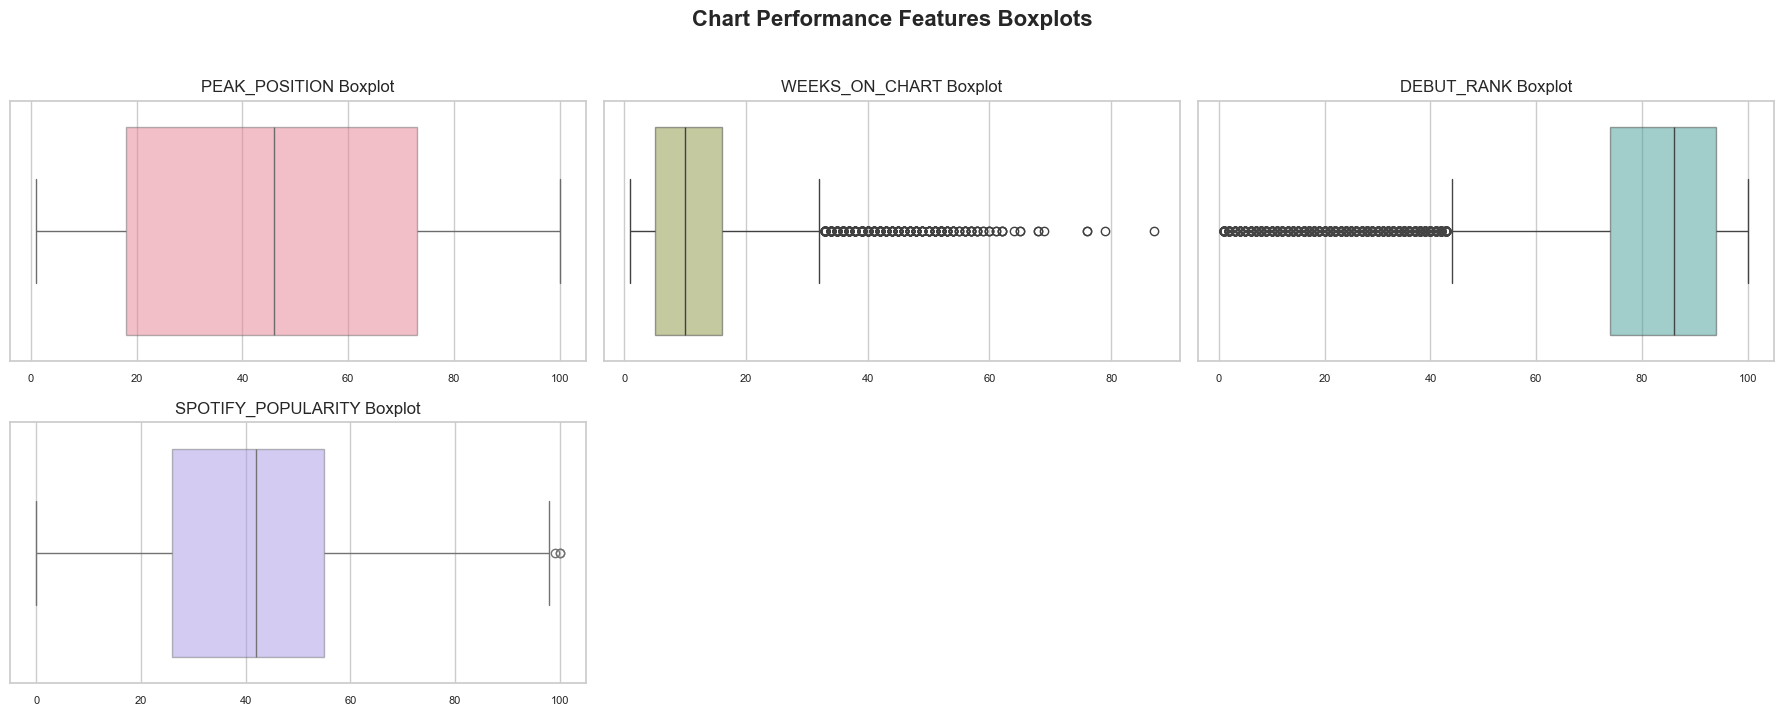

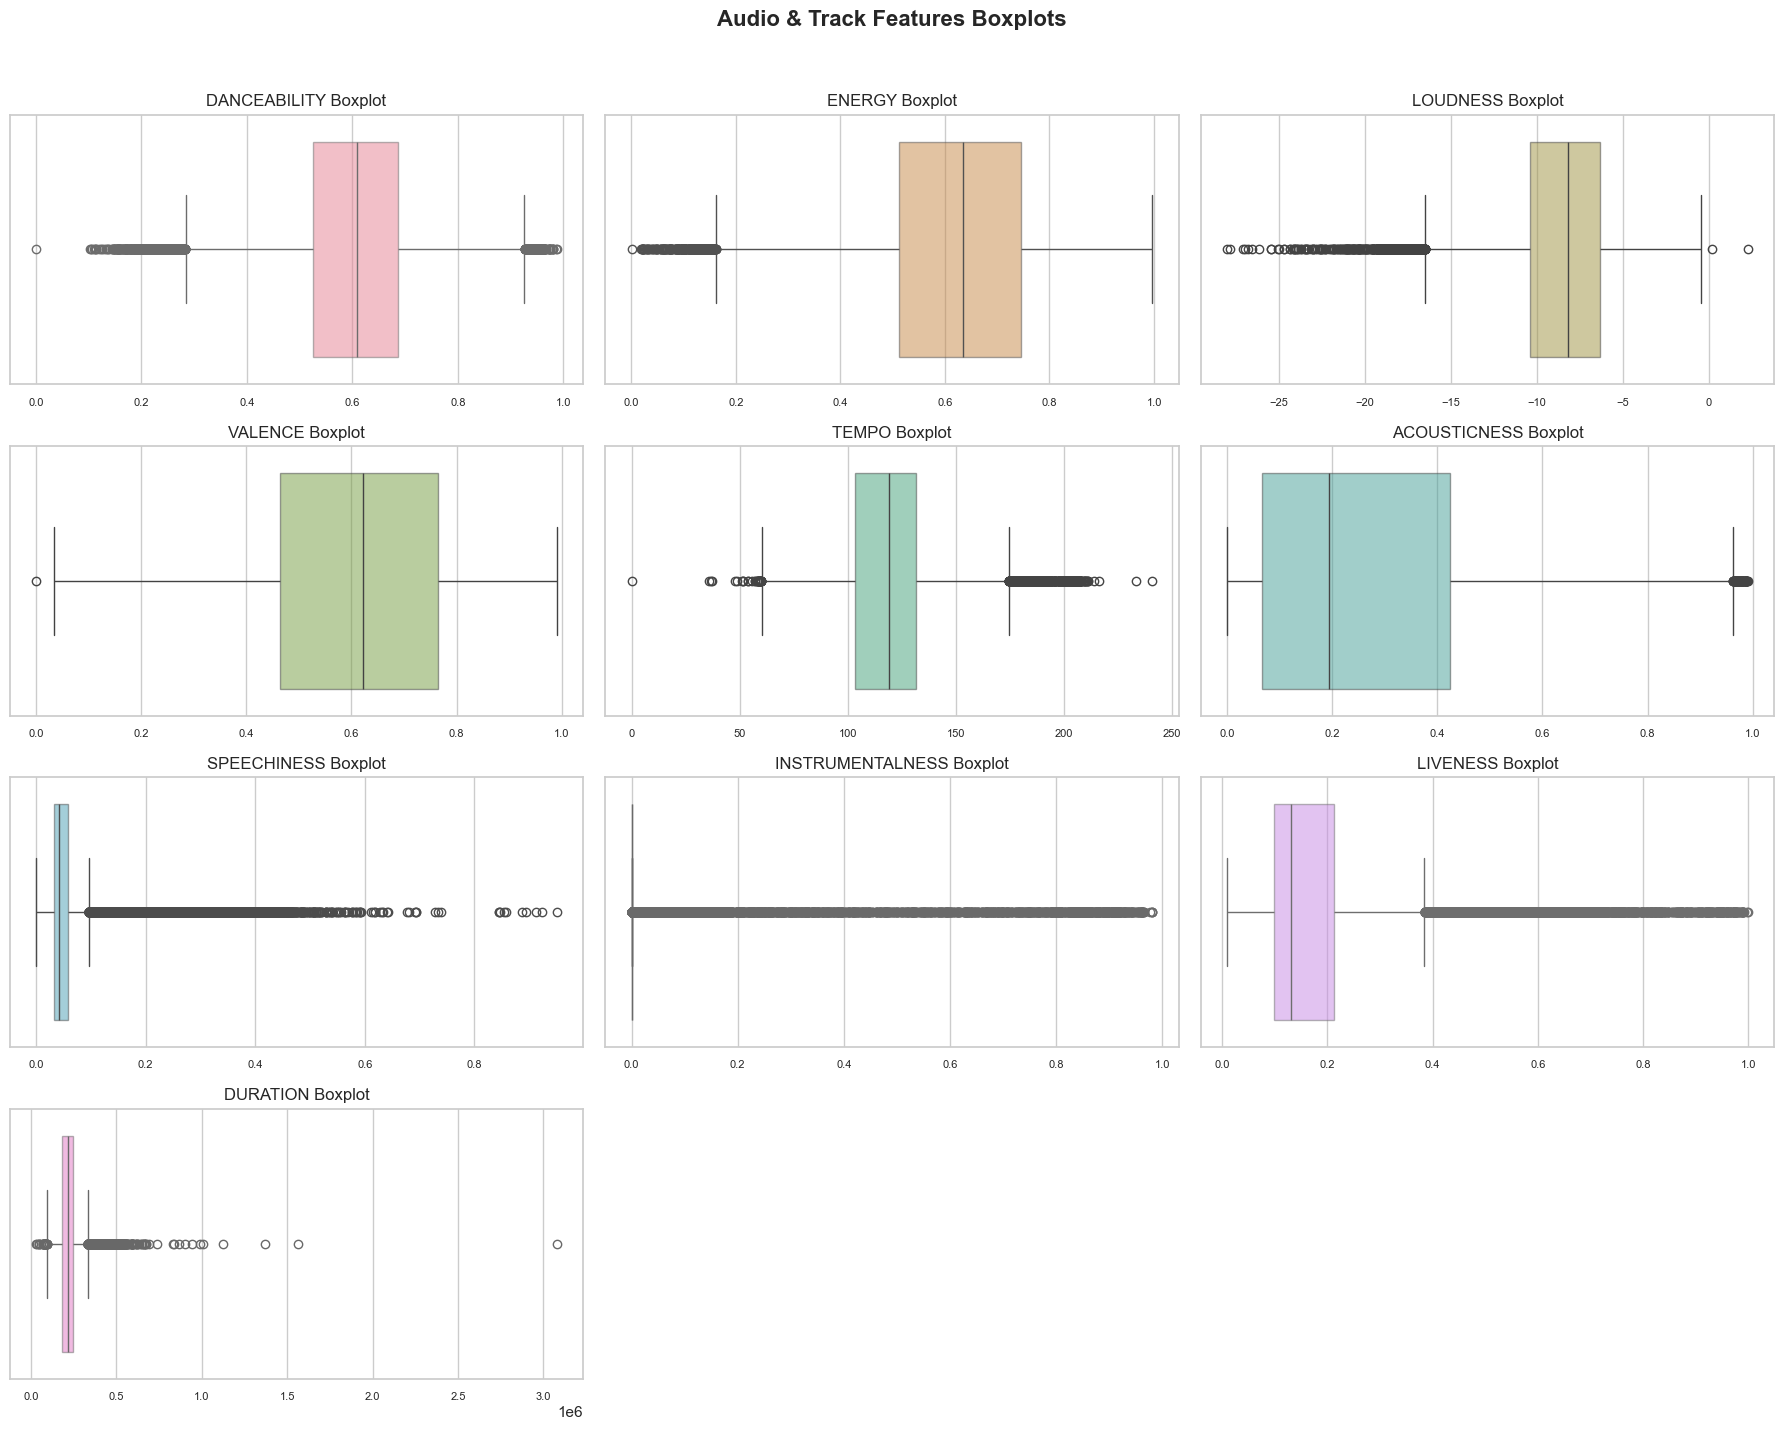

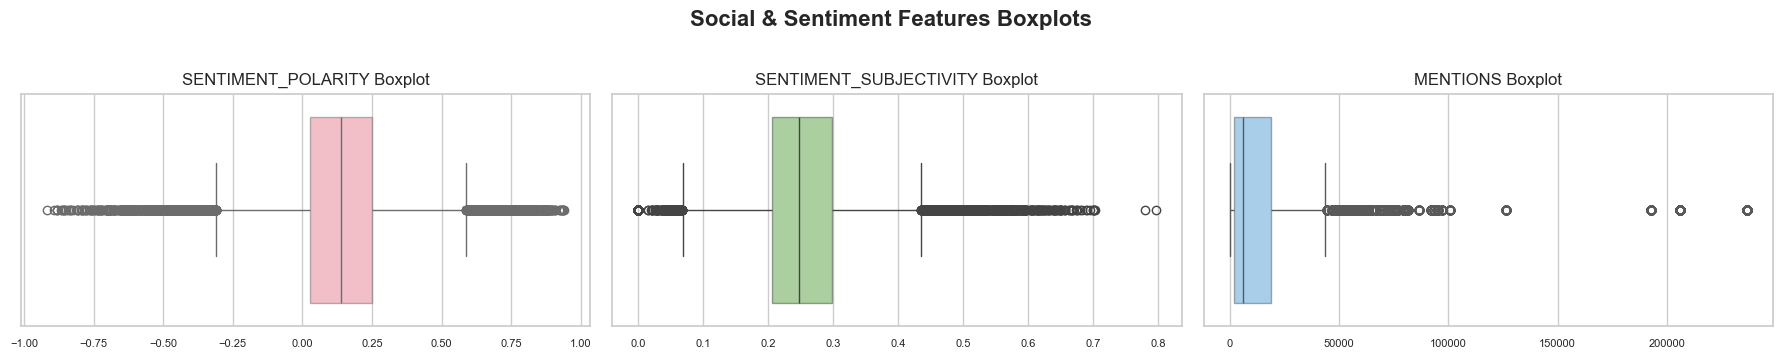

In [15]:
sns.set_theme(style="whitegrid")

chart_performance = [
    "PEAK_POSITION", "WEEKS_ON_CHART", "DEBUT_RANK", "SPOTIFY_POPULARITY"
]
audio_track = [
    "DANCEABILITY", "ENERGY", "LOUDNESS", "VALENCE", "TEMPO",
    "ACOUSTICNESS", "SPEECHINESS", "INSTRUMENTALNESS",
    "LIVENESS", "DURATION"
]
social = [
    "SENTIMENT_POLARITY", "SENTIMENT_SUBJECTIVITY", "MENTIONS"
]

# Chart Performance Boxplots
n_cols = 3
n_rows = int(np.ceil(len(chart_performance) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

colors = sns.color_palette("husl", len(chart_performance))

for idx, col in enumerate(chart_performance):
    ax = axes[idx]
    sns.boxplot(x=ms[col], ax=ax, color=colors[idx])
    ax.set_title(f"{col} Boxplot")
    ax.set_xlabel(None)
    ax.tick_params(axis='x', labelsize=8)
    for patch in ax.patches:
        patch.set_alpha(0.5)

# turn off unused axes
for j in range(idx + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Chart Performance Features Boxplots", fontsize=16, weight="bold", y=1.02)
plt.tight_layout()
plt.show()


# Audio & Track Boxplots
n_cols = 3
n_rows = int(np.ceil(len(audio_track) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

colors = sns.color_palette("husl", len(audio_track))

for idx, col in enumerate(audio_track):
    ax = axes[idx]
    sns.boxplot(x=ms[col], ax=ax, color=colors[idx])
    ax.set_xlabel(None)
    ax.set_title(f"{col} Boxplot")
    ax.tick_params(axis='x', labelsize=8)
    for patch in ax.patches:
        patch.set_alpha(0.5)

for j in range(idx + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Audio & Track Features Boxplots", fontsize=16, weight="bold", y=1.02)
plt.tight_layout()
plt.show()


# Social & Sentiment Boxplots
n_cols = 3
n_rows = int(np.ceil(len(social) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

colors = sns.color_palette("husl", len(social))

for idx, col in enumerate(social):
    ax = axes[idx]
    sns.boxplot(x=ms[col], ax=ax, color=colors[idx])
    ax.set_xlabel(None)
    ax.set_title(f"{col} Boxplot")
    ax.tick_params(axis='x', labelsize=8)
    for patch in ax.patches:
        patch.set_alpha(0.5)

for j in range(idx + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Social & Sentiment Features Boxplots", fontsize=16, weight="bold", y=1.02)
plt.tight_layout()
plt.show()


##### Outlier Treatment for Numerical Features (17)

**Chart Performance**: Even though the chart features are ordinal, they should be modeled as continuous numeric variables, not categorical bins, because their numeric ordering and spacing contain meaningful predictive information.

| Feature            | Action                                          | Rationale (from actual distribution)                             |
| ------------------ | ----------------------------------------------- | ---------------------------------------------------------------- |
| **PEAK_POSITION**  | No treatment                                    | Min=1, Max=100; ordinal; all values valid                        |
| **WEEKS_ON_CHART** | No outlier treatment                        | Max=87 is real hit longevity; distribution healthy; no anomalies |
| **DEBUT_RANK**     | No treatment                                    | Min=1, Max=100; ordinal; all values valid                        |
| **SPOTIFY_POPULARITY**     | No outlier treatment | Bounded (0–100); distribution stable                             |

**Audio & Track Attributes**
| Feature              | Action                   | Rationale (based on real values)                                                        |
| -------------------- | ------------------------ | --------------------------------------------------------------------------------------- |
| **DANCEABILITY**     | No treatment             | Bounded 0–1; quartiles tight; no outliers                                               |
| **ENERGY**           | No treatment             | Bounded 0–1; distribution clean                                                         |
| **LOUDNESS**         | **Light winsorization**  | Rare extreme near 0 dB; technically possible but likely artifacts                       |
| **VALENCE**          | No treatment             | Bounded; stable                                                                         |
| **TEMPO**            | **Light winsorization**  | Max=241 BPM; tail real but rarely above 230; capping avoids tiny number of weird values |
| **ACOUSTICNESS**     | No treatment             | Natural long-tail; expected                                                             |
| **SPEECHINESS**      | No treatment             | Spike at 0 is real (non-speech tracks)                                                  |
| **INSTRUMENTALNESS** | No treatment             | Long tail expected; zeros normal                                                        |
| **LIVENESS**         | No treatment             | Mild skew but valid                                                                     |
| **DURATION**         | **Strong winsorization** | Max=3,079,157 ms is extreme; >600k ms unrealistic for single tracks; remove distortion  |

**Social & Sentiment Features**
| Feature                    | Action                                               | Rationale                                                                                      |
| -------------------------- | ---------------------------------------------------- | ---------------------------------------------------------------------------------------------- |
| **SENTIMENT_POLARITY**     | No transformation                                    | Bounded (–1 to 1); organic distribution                                                        |
| **SENTIMENT_SUBJECTIVITY** | No transformation                                    | Bounded (0–1); mild skew but real                                                              |
| **MENTIONS**               | Log-transform during feature engineering later | Extremely heavy right skew; log transform improves modeling |

##### 4.4 Treat Outliers

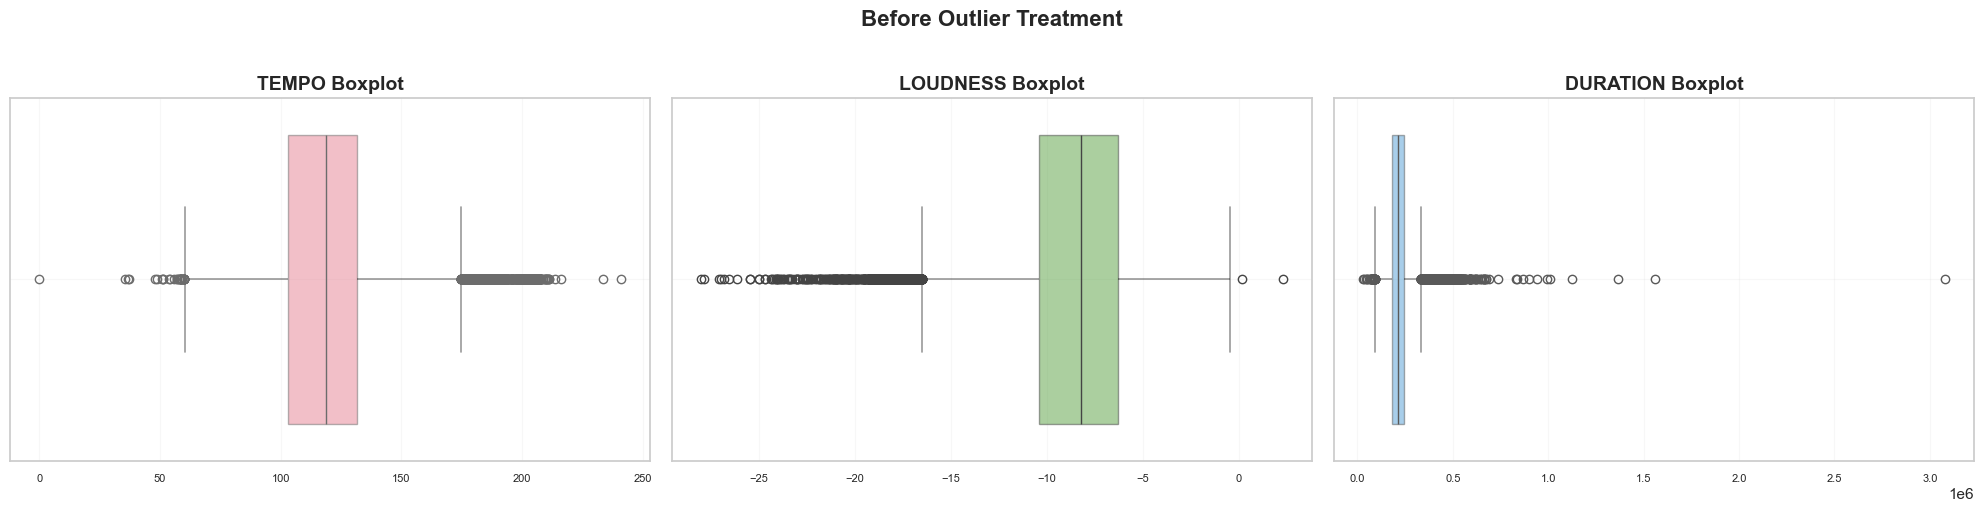

In [16]:
sns.set_theme(style="whitegrid")

features = ["TEMPO", "LOUDNESS", "DURATION"]
colors = sns.color_palette("husl", len(features))

# Create a 1 x 3 grid of subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 5))  # wider figure for 3 plots

for idx, col in enumerate(features):
    ax = axes[idx]
    
    sns.boxplot(x=ms[col], ax=ax, color=colors[idx])
    
    # Semi-transparent fill
    for patch in ax.patches:
        patch.set_alpha(0.5)
    
    # Soften gridlines
    ax.grid(True, alpha=0.15, linewidth=0.8)

    # Reduce tick font size
    ax.tick_params(axis='x', labelsize=8)

    # Remove x-axis label
    ax.set_xlabel(None)

    # Soften + recolor only the box outline (first 4 lines)
    box_lines = ax.lines[:4]
    for line in box_lines:
        line.set_color("black")
        line.set_alpha(0.4)
        line.set_linewidth(1.2)

    ax.set_title(f"{col} Boxplot", fontsize=14, weight="bold")

fig.suptitle("Before Outlier Treatment", fontsize=16, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# Outlier Treatment using IQR (Uniform 1.5 × IQR Rule)

def iqr_cap(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

print("Applying IQR-based outlier treatment (1.5*IQR) to TEMPO, LOUDNESS, DURATION.")

ms["TEMPO"] = iqr_cap(ms["TEMPO"])
ms["LOUDNESS"] = iqr_cap(ms["LOUDNESS"])
ms["DURATION"] = iqr_cap(ms["DURATION"])

print("Completed 4.4 Outlier Treatment.")
print(ms[["TEMPO", "LOUDNESS", "DURATION"]].describe())

Applying IQR-based outlier treatment (1.5*IQR) to TEMPO, LOUDNESS, DURATION.
Completed 4.4 Outlier Treatment.
              TEMPO      LOUDNESS       DURATION
count  29410.000000  29410.000000   29410.000000
mean     119.619587     -8.548889  217417.476432
std       24.346947      3.152578   50086.571998
min       60.418875    -16.501875   93609.125000
25%      103.239750    -10.395750  183883.250000
50%      118.921000     -8.210000  215093.000000
75%      131.787000     -6.325000  244066.000000
max      174.607875     -0.218875  334340.125000


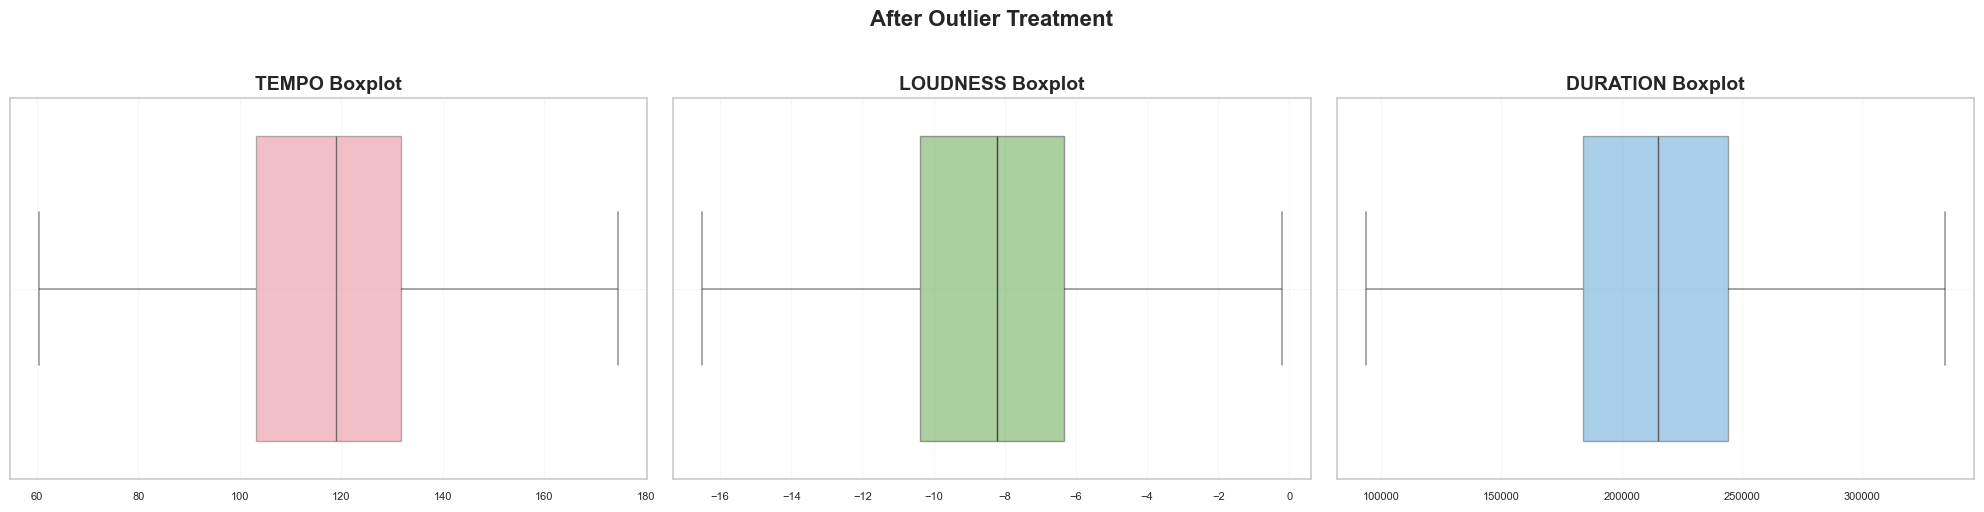

In [18]:
sns.set_theme(style="whitegrid")

features = ["TEMPO", "LOUDNESS", "DURATION"]
colors = sns.color_palette("husl", len(features))

# Create a 1 x 3 grid of subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 5))  # wider figure for 3 plots

for idx, col in enumerate(features):
    ax = axes[idx]
    
    sns.boxplot(x=ms[col], ax=ax, color=colors[idx])
    
    # Semi-transparent fill
    for patch in ax.patches:
        patch.set_alpha(0.5)
    
    # Soften gridlines
    ax.grid(True, alpha=0.15, linewidth=0.8)

    # Reduce tick font size
    ax.tick_params(axis='x', labelsize=8)

    # Remove x-axis label
    ax.set_xlabel(None)

    # Soften + recolor only the box outline (first 4 lines)
    box_lines = ax.lines[:4]
    for line in box_lines:
        line.set_color("black")
        line.set_alpha(0.4)
        line.set_linewidth(1.2)

    ax.set_title(f"{col} Boxplot", fontsize=14, weight="bold")

fig.suptitle("After Outlier Treatment", fontsize=16, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

##### 4.5 Check for Multicollinearity

,PEAK_POSITION,WEEKS_ON_CHART,DEBUT_RANK,SPOTIFY_POPULARITY,TEMPO,LOUDNESS,DURATION,SENTIMENT_POLARITY,SENTIMENT_SUBJECTIVITY,MENTIONS
PEAK_POSITION,1.000000,-0.711266,0.467545,-0.258645,0.005584,0.032059,-0.062595,-0.010165,0.004829,-0.094929
WEEKS_ON_CHART,-0.711266,1.000000,-0.210215,0.350056,-0.008725,0.105399,0.194942,0.014564,-0.002175,-0.027525
DEBUT_RANK,0.467545,-0.210215,1.000000,-0.300424,-0.011966,-0.139497,-0.090176,-0.038311,-0.021381,-0.294735
SPOTIFY_POPULARITY,-0.258645,0.350056,-0.300424,1.000000,0.032378,0.343796,0.215197,0.083892,0.004351,0.242816
TEMPO,0.005584,-0.008725,-0.011966,0.032378,1.000000,0.096328,-0.017858,-0.006101,-0.000488,0.023698
LOUDNESS,0.032059,0.105399,-0.139497,0.343796,0.096328,1.000000,0.065436,0.027410,0.009159,0.112386
DURATION,-0.062595,0.194942,-0.090176,0.215197,-0.017858,0.065436,1.000000,0.026540,0.035764,0.025479
SENTIMENT_POLARITY,-0.010165,0.014564,-0.038311,0.083892,-0.006101,0.027410,0.026540,1.000000,0.251313,0.107641
SENTIMENT_SUBJECTIVITY,0.004829,-0.002175,-0.021381,0.004351,-0.000488,0.009159,0.035764,0.251313,1.000000,0.099554
MENTIONS,-0.094929,-0.027525,-0.294735,0.242816,0.023698,0.112386,0.025479,0.107641,0.099554,1.000000


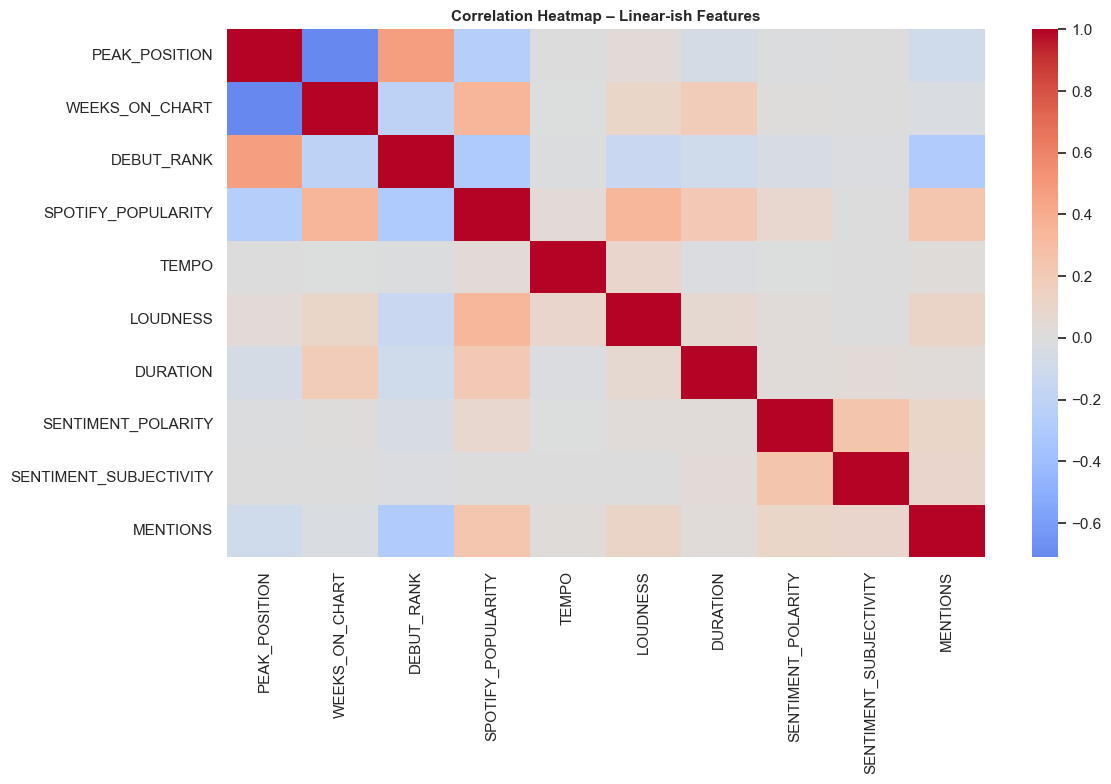

In [19]:
# Linear-ish numeric features only
linear_features = [
    "PEAK_POSITION",
    "WEEKS_ON_CHART",
    "DEBUT_RANK",
    "SPOTIFY_POPULARITY",
    "TEMPO",
    "LOUDNESS",
    "DURATION",
    "SENTIMENT_POLARITY",
    "SENTIMENT_SUBJECTIVITY",
    "MENTIONS"   # raw (log transform later)
]

corr = ms[linear_features].corr(method="pearson")
display(corr)

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap – Linear-ish Features", fontsize=11, weight="bold")
plt.tight_layout()
plt.show()

- Only one strong correlation:
PEAK_POSITION ↔ WEEKS_ON_CHART (–0.71) — expected, not redundant.

- Moderate but acceptable:
DEBUT_RANK ↔ PEAK_POSITION (+0.47) — complementary, keep both.

- SPOTIFY_POPULARITY shows mild correlations with several features (+0.20–0.35) — all reasonable.

- Sentiment variables moderately related (+0.25) — no concern.

- All other correlations are weak → no multicollinearity.

Conclusion:
No features need removal. All linear-ish features are safe to keep.

##### 4.6 Analyze Temporal Audio Preferences

Anomalous observations with YEAR > 2021: 7108
Frequency of anomalous YEAR values:
YEAR
2058    353
2059    573
2060    608
2061    677
2062    659
2063    663
2064    716
2065    705
2066    740
2067    735
2068    679
Name: count, dtype: int64
Plotting distribution of release YEAR...


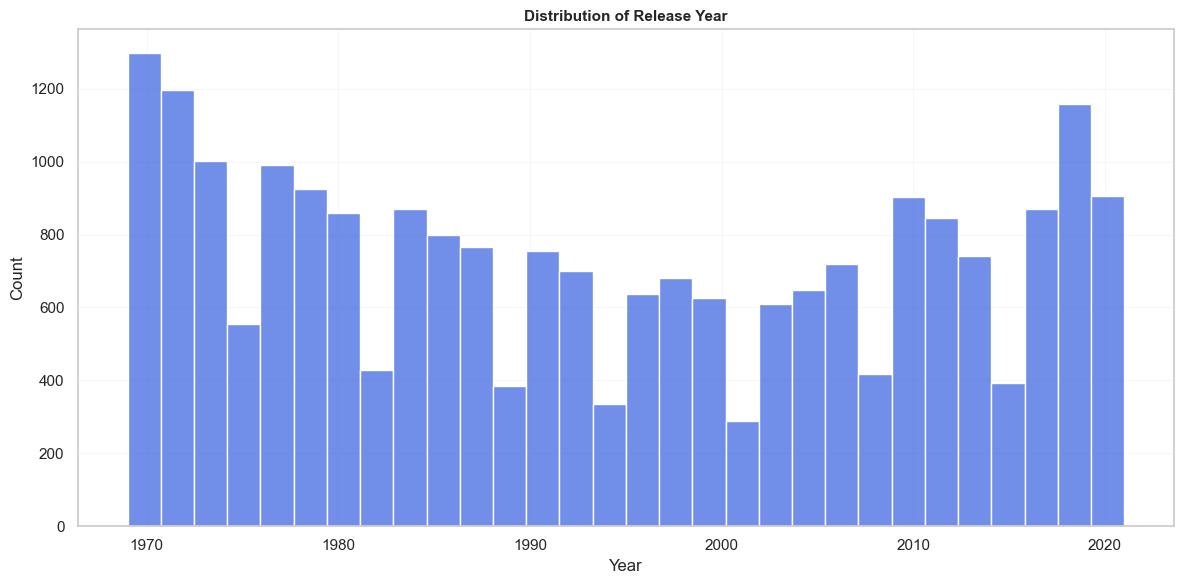

count    29410.000000
mean      2010.564978
std         33.102811
min       1969.000000
25%       1983.000000
50%       2003.500000
75%       2020.000000
max       2068.000000
Name: YEAR, dtype: float64


In [20]:
# Extract YEAR from FIRST_WEEK datetime column
ms["YEAR"] = ms["FIRST_WEEK"].dt.year

print(f"Anomalous observations with YEAR > 2021: {ms[ms['YEAR'] > 2021].shape[0]}")

# Create frequency table for YEAR
print(f"Frequency of anomalous YEAR values:\n{ms[ms['YEAR'] > 2021]['YEAR'].value_counts().sort_index()}")

print("Plotting distribution of release YEAR...")

plt.figure(figsize=(12, 6))
sns.histplot(ms[ms['YEAR'] <= 2021]['YEAR'], bins=30, kde=False, color="royalblue")
plt.title("Distribution of Release Year", fontsize=11, weight="bold")
ax = plt.gca()
ax.grid(True, alpha=0.15, linewidth=0.8)

plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Check basic stats for the new YEAR column
print(ms["YEAR"].describe())

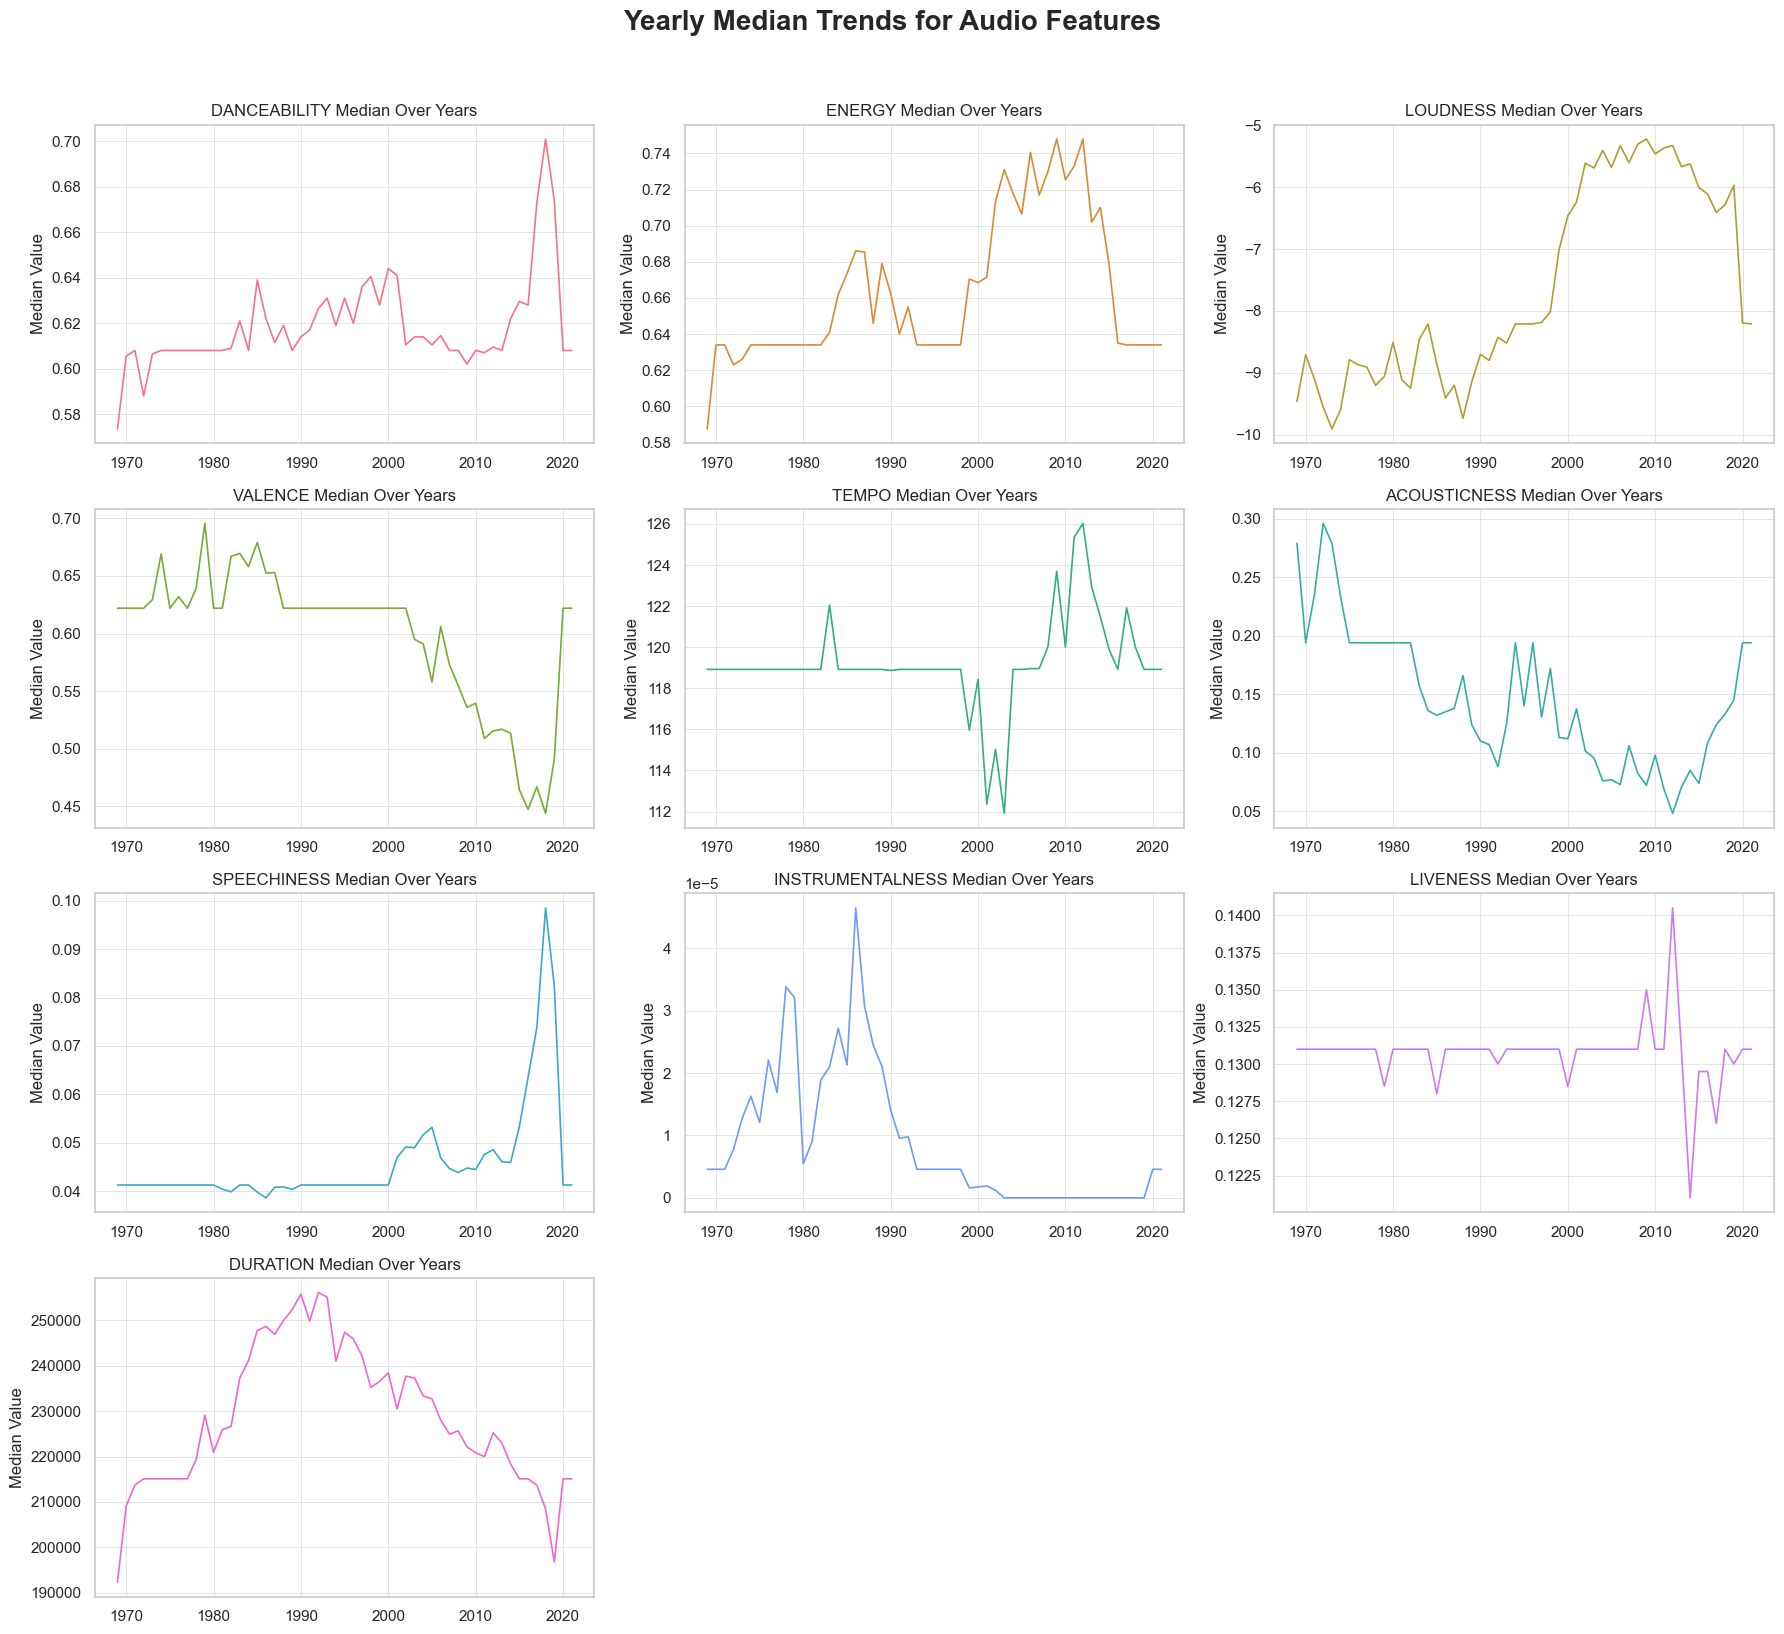

In [21]:
sns.set_theme(style="whitegrid")

# Soften gridlines
plt.rc('grid', color='0.85', linestyle='-', linewidth=0.5)

# Valid-year subset for temporal EDA only
ms_valid_years = ms[ms["YEAR"] <= 2021].copy()

audio_features = [
    "DANCEABILITY", "ENERGY", "LOUDNESS", "VALENCE", "TEMPO",
    "ACOUSTICNESS", "SPEECHINESS", "INSTRUMENTALNESS",
    "LIVENESS", "DURATION"
]

# Compute median by YEAR for each feature
yearly_medians = ms_valid_years.groupby("YEAR")[audio_features].median()

# Plotting
n_cols = 3
n_rows = int(np.ceil(len(audio_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

colors = sns.color_palette("husl", len(audio_features))

for idx, feature in enumerate(audio_features):
    axes[idx].plot(yearly_medians.index, yearly_medians[feature], 
                   color=colors[idx], linewidth=1.2)
    axes[idx].set_title(f"{feature} Median Over Years")
    axes[idx].set_xlabel(None)
    axes[idx].set_ylabel("Median Value")

# Turn off unused axes
for j in range(idx + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Yearly Median Trends for Audio Features",
             fontsize=20, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

- Energy and loudness rose steadily from the 1980s to the 2010s, suggesting a growing preference for high-energy, digitally produced songs until a recent tapering off.

- Acousticness and instrumentalness declined over time, indicating a shift away from acoustic and instrumental compositions toward heavily produced, vocal-centric music.

- Valence shows a downward trend in the last decade, reflecting the rise of moodier, lower-positivity genres such as trap and “sad pop.”

- Speechiness increases sharply in the 2010s, signaling the growing dominance of rap and hip-hop influences in mainstream charts.

- Song duration has shortened in recent years, likely driven by streaming-era optimization where shorter tracks perform better.

- Tempo fluctuates but trends slightly upward post-2010, consistent with faster-paced production becoming more common in modern pop and hip-hop.-

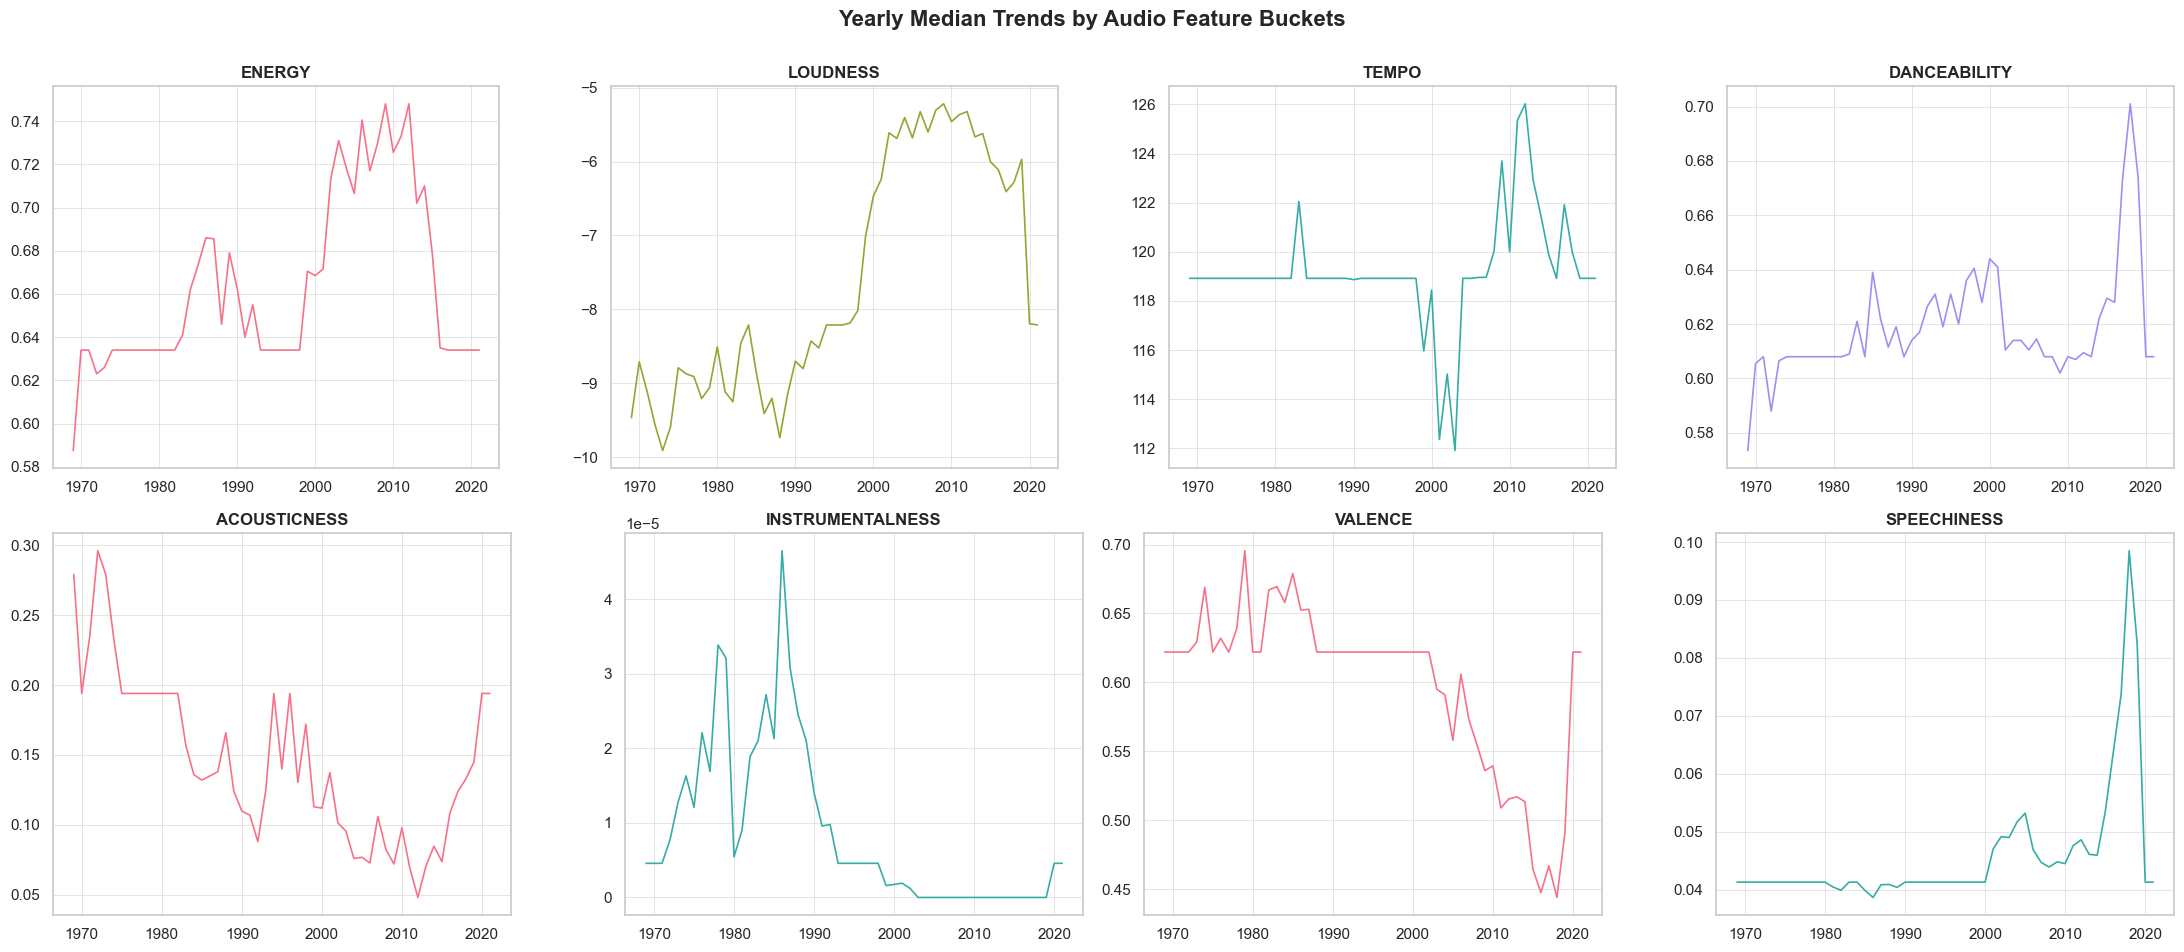

In [22]:
# Bucket and plot audio features of interest

sns.set_theme(style="whitegrid")
plt.rc('grid', color='0.85', linestyle='-', linewidth=0.5)

# Valid-year subset
ms_valid_years = ms[ms["YEAR"] <= 2021].copy()

# Buckets
bucket1 = ["ENERGY", "LOUDNESS", "TEMPO", "DANCEABILITY"]
bucket2 = ["ACOUSTICNESS", "INSTRUMENTALNESS"]
bucket3 = ["VALENCE", "SPEECHINESS"]

all_features = bucket1 + bucket2 + bucket3
yearly_medians = ms_valid_years.groupby("YEAR")[all_features].median()

# ==========================================================
# MASTER LAYOUT
# Row 1  → Bucket 1 full width
# Row 2  → left = Bucket 2, right = Bucket 3
# ==========================================================
fig = plt.figure(figsize=(22, 10))
gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 1])

# ==========================================================
# BUCKET 1 → (1 row × 4 columns), full width (gs[0, :])
# ==========================================================
gs_b1 = GridSpecFromSubplotSpec(
    1, len(bucket1), subplot_spec=gs[0, :], wspace=0.25
)

colors1 = sns.color_palette("husl", len(bucket1))

for i, feature in enumerate(bucket1):
    ax = fig.add_subplot(gs_b1[0, i])
    ax.plot(yearly_medians.index, yearly_medians[feature],
            color=colors1[i], linewidth=1.2)
    ax.set_title(feature, fontsize=12, weight="bold")
    ax.set_xlabel(None)

# ==========================================================
# BUCKET 2 → (1 row × 2 columns), bottom-left (gs[1, 0])
# ==========================================================
gs_b2 = GridSpecFromSubplotSpec(
    1, len(bucket2), subplot_spec=gs[1, 0], wspace=0.25
)

colors2 = sns.color_palette("husl", len(bucket2))

for i, feature in enumerate(bucket2):
    ax = fig.add_subplot(gs_b2[0, i])
    ax.plot(yearly_medians.index, yearly_medians[feature],
            color=colors2[i], linewidth=1.2)
    ax.set_title(feature, fontsize=12, weight="bold")
    ax.set_xlabel(None)

# ==========================================================
# BUCKET 3 → (1 row × 2 columns), bottom-right (gs[1, 1])
# ==========================================================
gs_b3 = GridSpecFromSubplotSpec(
    1, len(bucket3), subplot_spec=gs[1, 1], wspace=0.25
)

colors3 = sns.color_palette("husl", len(bucket3))

for i, feature in enumerate(bucket3):
    ax = fig.add_subplot(gs_b3[0, i])
    ax.plot(yearly_medians.index, yearly_medians[feature],
            color=colors3[i], linewidth=1.2)
    ax.set_title(feature, fontsize=12, weight="bold")
    ax.set_xlabel(None)

# ==========================================================
# TITLE + LAYOUT FIX
# ==========================================================
fig.suptitle(
    "Yearly Median Trends by Audio Feature Buckets",
    fontsize=16, weight="bold", y=0.95
)

fig.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

##### 4.7 Cleanup and Consolidate Genres

In [23]:
# Expanded mapping keywords for each macro-genre
genre_map = {
    "Pop": [
        # general pop
        "pop", "dance pop", "electropop", "indie pop", "power pop", "teen pop",
        "post-teen", "brill", "bubblegum",
        # adult contemporary / mellow / vocal pop
        "adult standards", "deep adult standards", "mellow", "mellow gold",
        "easy listening", "neo mellow", "glee", "a cappella", "idol",
        "talent show", "hollywood",
        # oldies pop styles
        "doo-wop", "girl group", "british invasion", "surf", "beach music"
    ],

    "Rock": [
        "rock", "album rock", "classic rock", "modern rock",
        "hard rock", "soft rock", "alternative rock", "folk rock",
        "southern rock", "punk", "goth",
        # metal variants
        "metal", "alternative metal", "glam metal", "heavy metal"
    ],

    "Country": [
        "country", "contemporary country", "country pop", "country rock",
        "americana", "bluegrass", "red dirt", "outlaw country",
        "honky tonk", "nashville sound", "cowboy"
    ],

    "Hip-Hop/Rap": [
        "rap", "hip hop", "trap", "gangster", "atl", "boom bap",
        "southern hip hop", "crunk", "pop rap"
    ],

    "R&B/Soul/Funk": [
        "r&b", "soul", "funk", "motown", "quiet storm",
        "neo-soul", "disco", "blues r&b"
    ],

    "EDM/Electronic": [
        "edm", "house", "techno", "electronic", "electro",
        "trance", "dubstep", "drum and bass", "synthwave",
        "industrial", "eurodance", "freestyle", "alternative dance"
    ],

    "Latin": [
        "latin", "reggaeton", "bachata", "salsa",
        "cumbia", "mambo", "merengue", "tropical"
    ],

    "Jazz/Blues": [
        "jazz", "swing", "bebop", "smooth jazz",
        "blues", "contemporary blues"
    ],

    "Folk/Acoustic": [
        "folk", "acoustic", "singer-songwriter",
        "indie acoustic", "chamber pop"
    ],

    "Other": []  # fallback bucket
}


# Function to map micro-genre to macro-genre
def map_genre(g):
    g = str(g).lower()

    for macro, keywords in genre_map.items():
        for kw in keywords:
            if kw in g:
                return macro

    return "Other"


# Apply mapping
ms["GENRE_CLEAN"] = ms["GENRE"].apply(map_genre)

# Check new distribution
ms["GENRE_CLEAN"].value_counts()

GENRE_CLEAN
Pop               10318
Other              5349
Rock               4583
R&B/Soul/Funk      3187
Hip-Hop/Rap        2545
Country            2030
Jazz/Blues          457
EDM/Electronic      402
Latin               303
Folk/Acoustic       236
Name: count, dtype: int64

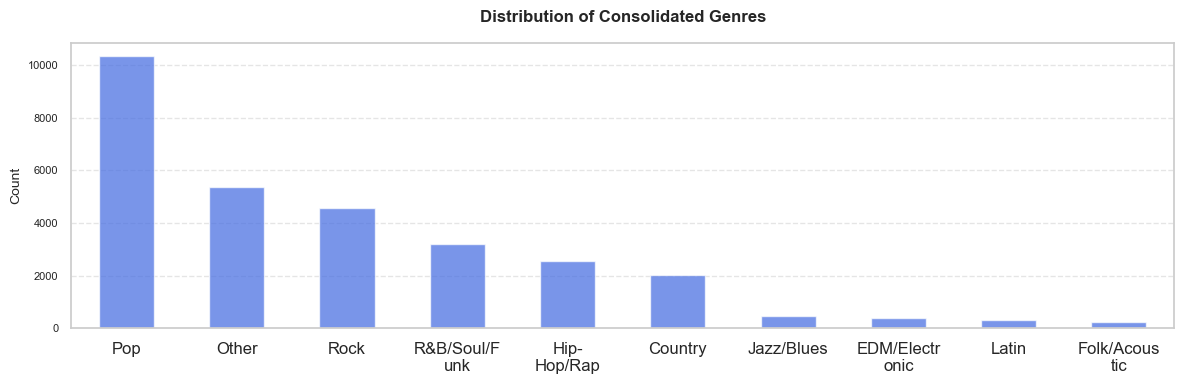

In [24]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 4))
ax = ms["GENRE_CLEAN"].value_counts().plot(kind="bar", color="royalblue", alpha=0.7)

ax.set_title("Distribution of Consolidated Genres", fontsize=12, weight="bold", pad=15)
ax.set_xlabel(None)
ax.set_ylabel("Count", fontsize=10)

# Extract tick label text and wrap each
labels = [textwrap.fill(t.get_text(), width=10) for t in ax.get_xticklabels()]
ax.set_xticklabels(labels, fontsize=12, rotation=0, ha="center")
ax.tick_params(axis='y', labelsize=8)
# Keep only horizontal gridlines
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

### 5. Feature Engineering

##### 5.1 Transform Key Skewed Variables

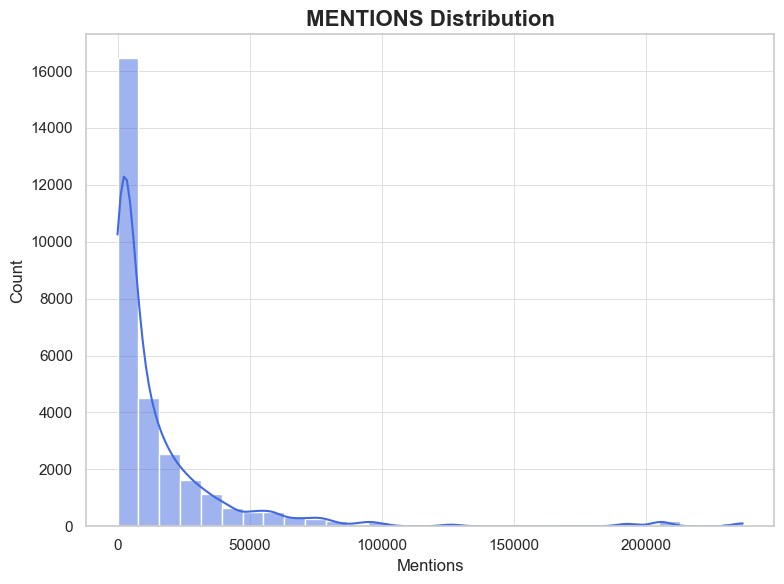

In [25]:
# Standalone Mentions Distribution (Soft Gridlines)

plt.figure(figsize=(8, 6))

# Soft gridlines
plt.grid(True, color="0.85", linewidth=0.6, linestyle="-")

sns.histplot(
    ms["MENTIONS"], bins=30, kde=True,
    color="#4169E1"
)

plt.title("MENTIONS Distribution", fontsize=16, weight="bold")
plt.xlabel("Mentions")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [26]:
# Log-transform MENTIONS (highly right-skewed)
ms["LOG_MENTIONS"] = np.log1p(ms["MENTIONS"])

# OPTIONAL: Log-transform DURATION — apply rule:
# If skewness > 1 → log-transform
if ms["DURATION"].skew() > 1:
    print(f"Applying log transform to DURATION due to high skewness: {ms['DURATION'].skew()}")
    ms["DURATION_LOG"] = np.log1p(ms["DURATION"])
else:
    print(f"No log transform applied to DURATION due to low skewness: {ms['DURATION'].skew()}")

# Check summary after transform
ms[[c for c in ms.columns if c in ["MENTIONS", "LOG_MENTIONS", "DURATION", "DURATION_LOG"]]].describe()

No log transform applied to DURATION due to low skewness: 0.36230734990751645


,DURATION,MENTIONS,LOG_MENTIONS
count,29410.000000,29410.000000,29410.000000
mean,217417.476432,16416.510847,8.596533
std,50086.571998,29719.841312,1.674484
min,93609.125000,0.000000,0.000000
25%,183883.250000,1863.000000,7.530480
50%,215093.000000,6006.000000,8.700681
75%,244066.000000,18797.000000,9.841506
max,334340.125000,236713.000000,12.374608


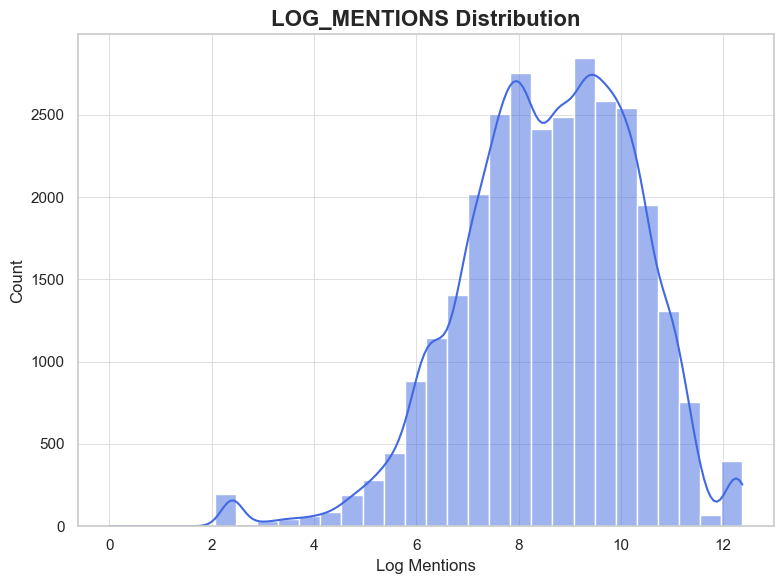

In [27]:
# Standalone LOG_MENTIONS Distribution

plt.figure(figsize=(8, 6))

# Soft gridlines
plt.grid(True, color="0.85", linewidth=0.6, linestyle="-")

sns.histplot(
    ms["LOG_MENTIONS"], bins=30, kde=True,
    color="#4169E1"
)

plt.title("LOG_MENTIONS Distribution", fontsize=16, weight="bold")
plt.xlabel("Log Mentions")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

##### 5.2 One-Hot Encode Categorical Variables

In [28]:
print(f"Shape before: {ms.shape}")

# Create one-hot encoded genre columns
genre_dummies = pd.get_dummies(ms["GENRE_CLEAN"], prefix="GENRE", drop_first=False)

# Add to dataframe
ms = pd.concat([ms, genre_dummies], axis=1)

print(f"Shape after: {ms.shape}")
print(f"Added genre dummy columns: {list(genre_dummies.columns)}")

Shape before: (29410, 29)
Shape after: (29410, 39)
Added genre dummy columns: ['GENRE_Country', 'GENRE_EDM/Electronic', 'GENRE_Folk/Acoustic', 'GENRE_Hip-Hop/Rap', 'GENRE_Jazz/Blues', 'GENRE_Latin', 'GENRE_Other', 'GENRE_Pop', 'GENRE_R&B/Soul/Funk', 'GENRE_Rock']


##### 5.3 Create HAS_PLAYLIST Dummy

In [29]:
print(f"Shape before: {ms.shape}")

# Playlist presence indicator
ms["HAS_PLAYLIST"] = ms["PLAYLIST_GENRE"].notna().astype(int)

# Drop raw playlist columns
ms = ms.drop(columns=["PLAYLIST_GENRE", "PLAYLIST_SUBGENRE"])

print(f"HAS_PLAYLIST distribution \n: {ms["HAS_PLAYLIST"].value_counts()}")
print(f"Shape after: {ms.shape}")

Shape before: (29410, 39)
HAS_PLAYLIST distribution 
: HAS_PLAYLIST
0    25941
1     3469
Name: count, dtype: int64
Shape after: (29410, 38)


### 6. Initial Feature Selection

##### 6.1 Drop Irrelevant / High-Cardinality Columns

In [30]:
print(f"Shape before: {ms.shape}")

# Drop irrelevant or high-cardinality columns
cols_to_drop = [
    "SONG", "ARTIST", "SONG_DISPLAY", "ARTIST_DISPLAY",
    "FIRST_WEEK", "YEAR"
]

ms = ms.drop(columns=cols_to_drop)

print(f"Dropped columns: {cols_to_drop}")
print(f"Shape after: {ms.shape}")
print(f"Final columns: {ms.columns.tolist()}")

Shape before: (29410, 38)
Dropped columns: ['SONG', 'ARTIST', 'SONG_DISPLAY', 'ARTIST_DISPLAY', 'FIRST_WEEK', 'YEAR']
Shape after: (29410, 32)
Final columns: ['HIT', 'PEAK_POSITION', 'WEEKS_ON_CHART', 'DEBUT_RANK', 'DANCEABILITY', 'ENERGY', 'LOUDNESS', 'VALENCE', 'TEMPO', 'ACOUSTICNESS', 'SPEECHINESS', 'INSTRUMENTALNESS', 'LIVENESS', 'SPOTIFY_POPULARITY', 'DURATION', 'GENRE', 'SENTIMENT_POLARITY', 'SENTIMENT_SUBJECTIVITY', 'MENTIONS', 'GENRE_CLEAN', 'LOG_MENTIONS', 'GENRE_Country', 'GENRE_EDM/Electronic', 'GENRE_Folk/Acoustic', 'GENRE_Hip-Hop/Rap', 'GENRE_Jazz/Blues', 'GENRE_Latin', 'GENRE_Other', 'GENRE_Pop', 'GENRE_R&B/Soul/Funk', 'GENRE_Rock', 'HAS_PLAYLIST']


##### 6.2 Assess Target Leakage

In [31]:
# 6.1.1 Correlation with HIT

# Select numeric predictors (exclude HIT itself)
numeric_features = ms.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_features = [c for c in numeric_features if c != "HIT"]

corr_with_hit = ms[numeric_features].corrwith(ms["HIT"]).sort_values(ascending=False)
print(corr_with_hit)

WEEKS_ON_CHART            0.518422
SPOTIFY_POPULARITY        0.242068
HAS_PLAYLIST              0.240159
LOG_MENTIONS              0.125023
MENTIONS                  0.050201
DANCEABILITY              0.049896
DURATION                  0.048948
VALENCE                   0.040105
ACOUSTICNESS              0.014890
SENTIMENT_POLARITY        0.003869
INSTRUMENTALNESS         -0.003163
SENTIMENT_SUBJECTIVITY   -0.004639
TEMPO                    -0.014984
LIVENESS                 -0.015920
SPEECHINESS              -0.019559
ENERGY                   -0.021615
LOUDNESS                 -0.029457
DEBUT_RANK               -0.301713
PEAK_POSITION            -0.621449
dtype: float64


*  No leakage is visible here (nothing near ±1 except chart-position relationships).
*  Don't use peak position for modeling.

In [32]:
# 6.1.2 Mutual Information with HIT

# Numeric predictors only (same list as before)
numeric_features = ms.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_features = [c for c in numeric_features if c != "HIT"]

X_num = ms[numeric_features]
y = ms["HIT"]

mi_scores = mutual_info_classif(X_num, y, random_state=42)
mi_series = pd.Series(mi_scores, index=numeric_features).sort_values(ascending=False)

print(mi_series)

PEAK_POSITION             0.455236
WEEKS_ON_CHART            0.155863
DEBUT_RANK                0.051999
MENTIONS                  0.041989
LOG_MENTIONS              0.039854
SENTIMENT_SUBJECTIVITY    0.037855
SPOTIFY_POPULARITY        0.036719
SENTIMENT_POLARITY        0.034705
HAS_PLAYLIST              0.023137
DANCEABILITY              0.009189
DURATION                  0.007391
ACOUSTICNESS              0.006915
TEMPO                     0.006857
INSTRUMENTALNESS          0.006304
ENERGY                    0.005234
SPEECHINESS               0.004078
LIVENESS                  0.003717
LOUDNESS                  0.003065
VALENCE                   0.001239
dtype: float64


In [33]:
# 6.1.3 Deterministic Relationship Check

deterministic_cols = []

for col in numeric_features:
    # nunique within HIT=0
    u0 = ms.loc[ms["HIT"] == 0, col].nunique()
    # nunique within HIT=1
    u1 = ms.loc[ms["HIT"] == 1, col].nunique()
    
    if u0 == 1 or u1 == 1:
        deterministic_cols.append((col, u0, u1))

print(f"Deterministic columns: {'NONE' if not deterministic_cols else deterministic_cols}")

Deterministic columns: NONE


##### 6.3 Assign Feature Importance Using Shallow Decision Tree

In [34]:
# Iterative Decision Tree Feature Importance (All Scenarios)

# Define exclusion combinations
exclusion_sets = {
    "1: Base (only GENRE columns excluded)": 
        ["HIT", "GENRE", "GENRE_CLEAN"],

    "2: Remove PEAK_POSITION": 
        ["HIT", "GENRE", "GENRE_CLEAN", "PEAK_POSITION"],

    "3: Remove PEAK_POSITION + WEEKS_ON_CHART": 
        ["HIT", "GENRE", "GENRE_CLEAN", "PEAK_POSITION", "WEEKS_ON_CHART"],

    "4: Remove PEAK_POSITION + WEEKS_ON_CHART + DEBUT_RANK": 
        ["HIT", "GENRE", "GENRE_CLEAN", "PEAK_POSITION", 
         "WEEKS_ON_CHART", "DEBUT_RANK"],
}

for label, exclude_cols in exclusion_sets.items():
    print("\n" + "="*80)
    print(f"Scenario {label}")
    print("Excluding:", exclude_cols)

    # Select features for this scenario
    feature_cols = [c for c in ms.columns if c not in exclude_cols]

    X = ms[feature_cols]
    y = ms["HIT"]

    # Train shallow decision tree
    dt_shallow = DecisionTreeClassifier(max_depth=4, random_state=42)
    dt_shallow.fit(X, y)

    # Extract importance
    importances = pd.Series(dt_shallow.feature_importances_, index=feature_cols)
    importances = importances[importances > 0].sort_values(ascending=False)

    print(f"\nNon-zero Feature Importances:\n{importances}")


Scenario 1: Base (only GENRE columns excluded)
Excluding: ['HIT', 'GENRE', 'GENRE_CLEAN']

Non-zero Feature Importances:
PEAK_POSITION             0.999518
TEMPO                     0.000306
SENTIMENT_SUBJECTIVITY    0.000161
GENRE_Country             0.000015
dtype: float64

Scenario 2: Remove PEAK_POSITION
Excluding: ['HIT', 'GENRE', 'GENRE_CLEAN', 'PEAK_POSITION']

Non-zero Feature Importances:
WEEKS_ON_CHART    0.769597
DEBUT_RANK        0.162253
DURATION          0.048154
GENRE_Country     0.019996
dtype: float64

Scenario 3: Remove PEAK_POSITION + WEEKS_ON_CHART
Excluding: ['HIT', 'GENRE', 'GENRE_CLEAN', 'PEAK_POSITION', 'WEEKS_ON_CHART']

Non-zero Feature Importances:
DEBUT_RANK            0.550706
SPOTIFY_POPULARITY    0.177321
HAS_PLAYLIST          0.124073
LOUDNESS              0.118041
GENRE_Hip-Hop/Rap     0.029859
dtype: float64

Scenario 4: Remove PEAK_POSITION + WEEKS_ON_CHART + DEBUT_RANK
Excluding: ['HIT', 'GENRE', 'GENRE_CLEAN', 'PEAK_POSITION', 'WEEKS_ON_CHART', 'DE

Tree-based Hierarchy:
- PEAK_POSITION
- WEEKS_ON_CHART
- DEBUT_RANK
- SPOTIFY_POPULARITY
- HAS_PLAYLIST
- LOUDNESS
- Genre Dummies
- DURATION
- DANCEABILITY
- ACOUSTICNESS
- All other features = minor but non-zero signal

### 7. Predictive Modeling

##### 7.1 Model Decision Tree Classifier

In [35]:
# 7.1.1 Create X and y

# Columns to exclude from X (as per base scenario)
exclude_cols = ["HIT", "GENRE", "GENRE_CLEAN", "MENTIONS", 'PEAK_POSITION', 'WEEKS_ON_CHART']

# Build X by excluding unwanted columns
X = ms.drop(columns=exclude_cols)

# Override based on feature importance from section 7.1.3
final_features = [
    "DEBUT_RANK",
    "SPOTIFY_POPULARITY",
    "HAS_PLAYLIST",
    "GENRE_Hip-Hop/Rap",
    "GENRE_Country",
    "LOUDNESS",
    "DURATION"
]

# Build X using ONLY the selected features
X = ms[final_features].copy()

# Target variable
y = ms["HIT"]

# Verify shapes
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Final X columns: {X.columns}")

X shape: (29410, 7)
y shape: (29410,)
Final X columns: Index(['DEBUT_RANK', 'SPOTIFY_POPULARITY', 'HAS_PLAYLIST', 'GENRE_Hip-Hop/Rap',
       'GENRE_Country', 'LOUDNESS', 'DURATION'],
      dtype='object')


In [36]:
# 7.1.2 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Train HIT distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Test HIT distribution:\n{y_test.value_counts(normalize=True)}")

Train shape: (20587, 7)
Test shape: (8823, 7)
Train HIT distribution:
HIT
0    0.830087
1    0.169913
Name: proportion, dtype: float64
Test HIT distribution:
HIT
0    0.830103
1    0.169897
Name: proportion, dtype: float64


Tree depth: 6
Number of leaves: 19
Importances:
DEBUT_RANK            0.420839
SPOTIFY_POPULARITY    0.230864
HAS_PLAYLIST          0.095216
GENRE_Hip-Hop/Rap     0.094314
GENRE_Country         0.067542
LOUDNESS              0.061826
DURATION              0.029400
dtype: float64


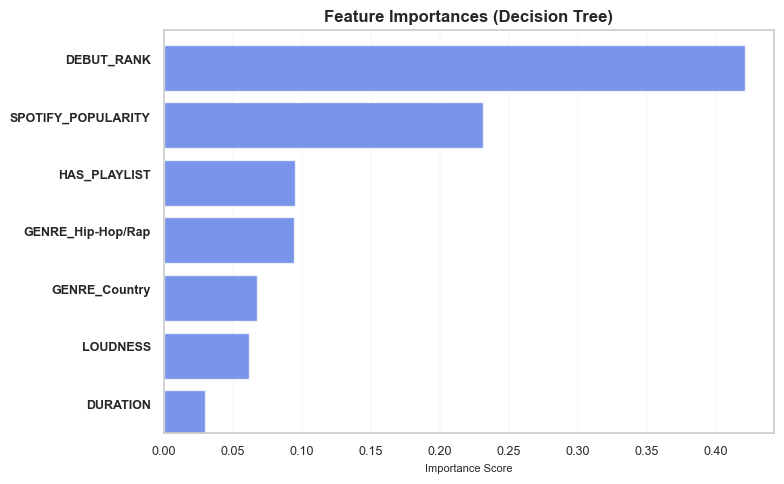

In [37]:
# 7.1.3 Train Decision Tree

dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight={0:1, 1:2},
    ccp_alpha=0.001,
    random_state=42
)

dt.fit(X_train, y_train)

print("Tree depth:", dt.get_depth())
print("Number of leaves:", dt.get_n_leaves())

# Derive feature importances
importances = pd.Series(dt.feature_importances_, index=X_train.columns)

# Keep only non-zero importances
importances = importances[importances > 0].sort_values(ascending=False)
print(f"Importances:\n{importances}")

# Plot feature importances
plt.figure(figsize=(8, 5))

ax = importances.plot(kind='barh', color="#4169E1", edgecolor=None, alpha=0.7)
# Reduce bar thickness → reduces vertical spacing
for bar in ax.patches:
    bar.set_height(0.8)


# Title and labels
plt.title("Feature Importances (Decision Tree)", fontsize=12, weight="bold")
plt.xlabel("Importance Score", fontsize=8)
plt.yticks(fontsize=10, weight="bold")

# Softer gridlines
plt.grid(axis='x', linestyle='-', linewidth=0.2, alpha=0.6)
plt.grid(axis='y', linestyle='None')

# Smaller tick fonts
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

# Reduce space between bars
plt.margins(y=0.02)

# Highest importance at top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [38]:
# 7.1.4 Evaluate Model

# Predictions
y_train_pred = dt.predict(X_train)
y_test_pred  = dt.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, digits=3))

# Extract confusion matrix values
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

# Positives (P) and Negatives (N)
P = tp + fn
N = tn + fp

# Metrics
TPR = tp / P      # Recall / Sensitivity
FNR = fn / P      # Type II Error
TNR = tn / N      # Specificity
FPR = fp / N      # Type I Error

print("\nAdditional Metrics for Decision Tree Classifier:")
print(f"TPR (Recall/Sensitivity): {TPR:.4f}")
print(f"FNR (Type II Error):      {FNR:.4f}")
print(f"TNR (Specificity):         {TNR:.4f}")
print(f"FPR (Type I Error):        {FPR:.4f}")

Training Accuracy: 0.8340214698596201
Testing Accuracy: 0.8272696361781707

Confusion Matrix:
[[6596  728]
 [ 796  703]]

Classification Report:
              precision    recall  f1-score   support

           0      0.892     0.901     0.896      7324
           1      0.491     0.469     0.480      1499

    accuracy                          0.827      8823
   macro avg      0.692     0.685     0.688      8823
weighted avg      0.824     0.827     0.826      8823


 Additional Metrics 
TPR (Recall/Sensitivity): 0.4690
FNR (Type II Error):      0.5310
TNR (Specificity):         0.9006
FPR (Type I Error):        0.0994


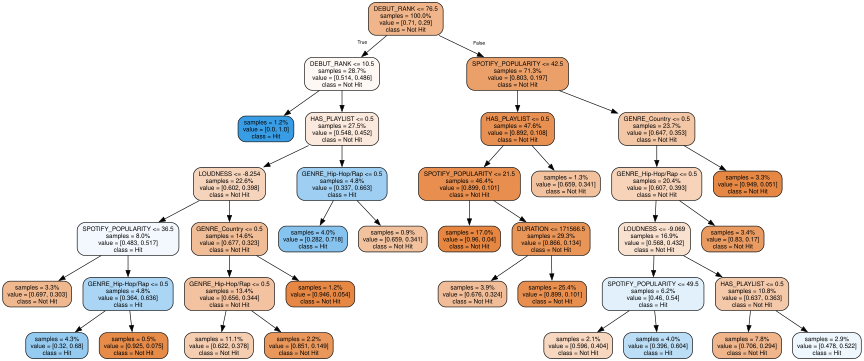

In [39]:
# 7.1.5 Plot Decision Tree with Graphviz

dot = export_graphviz(
    dt,
    out_file=None,
    feature_names=X_train.columns,
    class_names=["Not Hit", "Hit"],
    filled=True,
    rounded=True,
    proportion=True,
    impurity=False
)

# Reduce font sizes
dot = dot.replace(
    'node [shape=box, style="filled, rounded", color="black", fontname="helvetica"]',
    'node [shape=box, style="filled, rounded", color="black", fontname="helvetica", fontsize=10]'
)

dot = dot.replace(
    'edge [fontname="helvetica"]',
    'edge [fontname="helvetica", fontsize=8]'
)

# Insert size directive directly after "digraph Tree {"
dot = dot.replace(
    "digraph Tree {",
    'digraph Tree {\n  graph [size="12,6"];'
)

# Render
graph = graphviz.Source(dot)
graph

##### 7.2 Summarize Decision Tree Model and Insights

**Setup, Approach, and Performance**
- Removed leakage variables (Peak Position, Weeks on Chart).
- Retained audio features, Spotify metadata, genre dummies, and online engagement.
- Used model-based feature importance to reduce inputs to the strongest predictors. Ensures interpretability and avoids noise from unused variables.
- Balance is acceptable given the primary goal of producing a highly interpretable model.
- Avoids aggressive overfitting seen with deeper trees.
- Provides a stable trade-off between identifying hits and avoiding too many false alarms.
- Severe class imbalance limits model performance.
- Feature scope for for improving predictive power through advanced techniques to handle class imbalance – SMOTE.

**Results, Interpretation, and Insights**
- Debut Rank is the Strongest Predictor: This can be a strong early signal for timing the marketing spend. Streaming platform listening will hold the key.
- Streaming Platforms Play a Crucial Role: Streaming platforms provide the required exposure and accelerate success as evident from the - importance of Spotify Popularity and Playlist Presence.
- Hip-Hop/Rap and Country Genres: Genre influences split pathways, particularly Hip-Hop/Rap and Country. Directionality of the influence is unknown, though.
- Audio feature – Loudness: Consistent with the modern production trend of loud music. From earlier findings this singnals demand for audio that is high in energy, tempo, dancability etc.

---

- The tree’s first split is on Debut Rank, indicating early chart momentum drives overall outcomes.
- Subsequent splits rely on Spotify Popularity and Playlist Presence, emphasizing early exposure and listener traction.
- Leaf nodes reveal clear patterns: songs with strong early metrics cluster into high hit-probability paths, while lower-ranked tracks - consistently fall into non-hit branches.

##### 7.3 Model Logistic Regression

In [40]:
# 7.2.1 Prepare X and y

# Columns to remove for Logistic Regression
remove_cols = [
    "HIT",
    "GENRE",
    "GENRE_CLEAN",
    "MENTIONS",
    "PEAK_POSITION",
    "WEEKS_ON_CHART"
]

# Build X
X = ms.drop(columns=remove_cols)

# Target
y = ms["HIT"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"X columns:\n {X.columns}")

X shape: (29410, 26)
y shape: (29410,)
X columns:
 Index(['DEBUT_RANK', 'DANCEABILITY', 'ENERGY', 'LOUDNESS', 'VALENCE', 'TEMPO',
       'ACOUSTICNESS', 'SPEECHINESS', 'INSTRUMENTALNESS', 'LIVENESS',
       'SPOTIFY_POPULARITY', 'DURATION', 'SENTIMENT_POLARITY',
       'SENTIMENT_SUBJECTIVITY', 'LOG_MENTIONS', 'GENRE_Country',
       'GENRE_EDM/Electronic', 'GENRE_Folk/Acoustic', 'GENRE_Hip-Hop/Rap',
       'GENRE_Jazz/Blues', 'GENRE_Latin', 'GENRE_Other', 'GENRE_Pop',
       'GENRE_R&B/Soul/Funk', 'GENRE_Rock', 'HAS_PLAYLIST'],
      dtype='object')


In [41]:
# 7.2.2 Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"\nTrain HIT distribution:\n{y_train.value_counts(normalize=True)}")
print(f"\nTest HIT distribution:\n{y_test.value_counts(normalize=True)}")

Train shape: (20587, 26)
Test shape: (8823, 26)

Train HIT distribution:
HIT
0    0.830087
1    0.169913
Name: proportion, dtype: float64

Test HIT distribution:
HIT
0    0.830103
1    0.169897
Name: proportion, dtype: float64


In [42]:
# 7.2.3 Standardize Numeric Features

# Identify numeric columns (all except dummies/binary)
numeric_features = [
    'DEBUT_RANK', 'DANCEABILITY', 'ENERGY', 'LOUDNESS',
    'VALENCE', 'TEMPO', 'ACOUSTICNESS', 'SPEECHINESS', 'INSTRUMENTALNESS',
    'LIVENESS', 'SPOTIFY_POPULARITY', 'DURATION', 'SENTIMENT_POLARITY',
    'SENTIMENT_SUBJECTIVITY', 'LOG_MENTIONS'
]

# Fit scaler on training data only
scaler = StandardScaler()
X_train_scaled_num = scaler.fit_transform(X_train[numeric_features])
X_test_scaled_num  = scaler.transform(X_test[numeric_features])

# Convert back to DataFrames with same column names
X_train_scaled_num = pd.DataFrame(X_train_scaled_num, columns=numeric_features, index=X_train.index)
X_test_scaled_num  = pd.DataFrame(X_test_scaled_num,  columns=numeric_features, index=X_test.index)

# Keep non-numeric columns as-is
non_numeric_cols = [c for c in X_train.columns if c not in numeric_features]
X_train_final = pd.concat([X_train_scaled_num, X_train[non_numeric_cols]], axis=1)
X_test_final  = pd.concat([X_test_scaled_num,  X_test[non_numeric_cols]], axis=1)

print(f"X_train_final shape: {X_train_final.shape}")
print(f"X_test_final shape: {X_test_final.shape}")
print(f"Scaled columns: {numeric_features}")

X_train_final shape: (20587, 26)
X_test_final shape: (8823, 26)
Scaled columns: ['DEBUT_RANK', 'DANCEABILITY', 'ENERGY', 'LOUDNESS', 'VALENCE', 'TEMPO', 'ACOUSTICNESS', 'SPEECHINESS', 'INSTRUMENTALNESS', 'LIVENESS', 'SPOTIFY_POPULARITY', 'DURATION', 'SENTIMENT_POLARITY', 'SENTIMENT_SUBJECTIVITY', 'LOG_MENTIONS']


In [43]:
# 7.2.4 Fit Logistic Regression

lr = LogisticRegression(
    max_iter=300,
    solver="lbfgs"
)

lr.fit(X_train_final, y_train)

print("Model fitted. Converged:", lr.n_iter_)

Model fitted. Converged: [35]


In [44]:
# Determine best threshold based on F1 score (HIT=1)
y_test_proba = lr.predict_proba(X_test_final)[:, 1]

thresholds = [i/100 for i in range(1, 60)]  # 0.01 to 0.59
best_thresh = 0
best_f1 = 0

for t in thresholds:
    preds = (y_test_proba >= t).astype(int)
    f1 = f1_score(y_test, preds, pos_label=1)
    
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best Threshold:", best_thresh)
print("Best F1 (HIT=1):", best_f1)

Best Threshold: 0.19
Best F1 (HIT=1): 0.5077538769384692


In [45]:
# Determine best threshold based on Balanced Accuracy
y_test_proba = lr.predict_proba(X_test_final)[:, 1]

thresholds = [i/100 for i in range(1, 60)]  # 0.01 to 0.59
best_thresh = 0
best_bal_acc = 0

for t in thresholds:
    preds = (y_test_proba >= t).astype(int)
    bal_acc = balanced_accuracy_score(y_test, preds)
    
    if bal_acc > best_bal_acc:
        best_bal_acc = bal_acc
        best_thresh = t

print("Best Threshold (Balanced Accuracy):", best_thresh)
print("Best Balanced Accuracy:", best_bal_acc)

Best Threshold (Balanced Accuracy): 0.15
Best Balanced Accuracy: 0.7457856940126478


In [46]:
# 7.2.5 Evaluate Logistic Regression (with custom threshold)

# Predict probabilities
y_train_proba = lr.predict_proba(X_train_final)[:, 1]
y_test_proba  = lr.predict_proba(X_test_final)[:, 1]

# Custom threshold
threshold = 0.35

# Apply threshold
y_train_pred = (y_train_proba >= threshold).astype(int)
y_test_pred  = (y_test_proba  >= threshold).astype(int)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, digits=3))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_test_proba)
print(f"ROC-AUC Score: {roc_auc}")

# Extract confusion matrix components
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

P = tp + fn   # total actual positives
N = tn + fp   # total actual negatives

# Required metrics
TPR = tp / P   # Sensitivity / Recall
FNR = fn / P   # Type II Error Rate (beta)
TNR = tn / N   # Specificity
FPR = fp / N   # Type I Error Rate (alpha)

print("\n Additional Metrics ")
print(f"TPR (Recall/Sensitivity): {TPR:.4f}")
print(f"FNR (Type II Error):      {FNR:.4f}")
print(f"TNR (Specificity):        {TNR:.4f}")
print(f"FPR (Type I Error):       {FPR:.4f}")

Training Accuracy: 0.8400932627386215
Testing Accuracy: 0.8329366428652386

Confusion Matrix:
[[6722  602]
 [ 872  627]]

Classification Report:
              precision    recall  f1-score   support

           0      0.885     0.918     0.901      7324
           1      0.510     0.418     0.460      1499

    accuracy                          0.833      8823
   macro avg      0.698     0.668     0.680      8823
weighted avg      0.821     0.833     0.826      8823

ROC-AUC Score: 0.8063819353080462

 Additional Metrics 
TPR (Recall/Sensitivity): 0.4183
FNR (Type II Error):      0.5817
TNR (Specificity):        0.9178
FPR (Type I Error):       0.0822


In [47]:
# Copy training matrix
X_train_sm = X_train_final.copy()

# Convert boolean dummies to integers BEFORE fitting statsmodels Logit
bool_cols = X_train_sm.select_dtypes(include=['bool']).columns
X_train_sm[bool_cols] = X_train_sm[bool_cols].astype(int)

# Add intercept
X_sm = sm.add_constant(X_train_sm)
X_sm = X_sm.rename(columns={"const": "Intercept"})
X_sm = X_sm.drop(columns=["GENRE_Other"])

# Fit statsmodels Logit
logit_model = sm.Logit(y_train, X_sm)
logit_result = logit_model.fit()

# Output full summary
print(logit_result.summary())

print(f"{logit_result.summary2()}")

Optimization terminated successfully.
         Current function value: 0.357198
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                    HIT   No. Observations:                20587
Model:                          Logit   Df Residuals:                    20561
Method:                           MLE   Df Model:                           25
Date:                Sun, 30 Nov 2025   Pseudo R-squ.:                  0.2162
Time:                        17:27:05   Log-Likelihood:                -7353.6
converged:                       True   LL-Null:                       -9382.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -2.1065      0.059    -35.430      0.000      -2.223      

In [48]:
def significance_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    elif p < 0.1:
        return "."
    else:
        return ""

params = logit_result.params
conf   = logit_result.conf_int()
pvals  = logit_result.pvalues
se     = logit_result.bse

results_table = pd.DataFrame({
    "Estimate": params,
    "Std.Error":  se,
    "z":    params / se,
    "p-value":    pvals,
    "Signif":     pvals.apply(significance_stars),
    "OR":         np.exp(params),
    "OR 2.5%":    np.exp(conf[0]),
    "OR 97.5%":   np.exp(conf[1]),
})

pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

def color_pvals(val):
    """Color code based on p-value significance."""
    if val < 0.001:
        return "font-weight: bold; color: green;"       # highly significant
    elif val < 0.01:
        return "color: green;"                          # significant
    elif val < 0.05:
        return "color: darkgreen;"                      # weak significance
    elif val < 0.1:
        return "color: orange;"                         # marginal
    else:
        return "color: red;"                            # not significant

styled = results_table.sort_values(by=["p-value"]).style.map(color_pvals, subset=["p-value"])
styled

,Estimate,Std.Error,z,p-value,Signif,OR,OR 2.5%,OR 97.5%
Intercept,-2.106473,0.059454,-35.430446,0.000000,***,0.121666,0.108284,0.136703
DEBUT_RANK,-0.628128,0.020260,-31.002946,0.000000,***,0.533590,0.512817,0.555205
SPOTIFY_POPULARITY,0.765313,0.028798,26.575459,0.000000,***,2.149668,2.031696,2.274490
HAS_PLAYLIST,1.164097,0.062645,18.582393,0.000000,***,3.203029,2.832939,3.621467
VALENCE,0.468786,0.029590,15.842570,0.000000,***,1.598054,1.508009,1.693475
GENRE_Country,-1.628033,0.169575,-9.600671,0.000000,***,0.196315,0.140803,0.273714
LOUDNESS,-0.295226,0.032759,-9.011916,0.000000,***,0.744364,0.698072,0.793725
GENRE_Hip-Hop/Rap,-0.976511,0.117153,-8.335334,0.000000,***,0.376623,0.299354,0.473835
ACOUSTICNESS,0.233475,0.028646,8.150430,0.000000,***,1.262981,1.194026,1.335919
SPEECHINESS,-0.165128,0.027963,-5.905221,0.000000,***,0.847785,0.802571,0.895546


##### 7.4 Summarize Logistic Regression Model and Insights

**Setup, Approach, and Performance**
- Removed leakage variables (Peak Position, Weeks on Chart).
- Retained audio features, Spotify metadata, genre dummies, and playlist presence.
- Standardized all numeric predictors as the model is vulnerable to difference in scales.
- Performance is strong despite the severe class imbalance (17% hits), with logistic regression producing a stable linear decision boundary.
- Recall is intentionally moderated to reduce excessive false alarms, producing a cleaner, more conservative hit-prediction signal.
- ROC-AUC = 0.806, indicating the model captures meaningful probability ranking of HIT vs NON-HIT
- Consider regularized LR (L1/L2) to refine coefficient stability and address multicollinearity in genre dummies.
- Evaluated thresholds from 0.01 to 0.59 and chose 0.35 as the final operating point as it offered the best trade-off between precision (0.- 51) and recall (0.418).
- Avoids excessive false positives at lower thresholds (0.15–0.19). Maintains high model stability and interpretability.

**Results, Interpretation, and Insights**
- Debut Rank Is the Most Influential Predictor: Debut Rank carries the strongest negative coefficient, meaning early chart trends signal HIT potential and Record Labels should strategize marketing effort based on such indication.
- Streaming Platform Signals Drive Hit Probability: Spotify Popularity and Playlist Presence show large, positive, and highly significant - coefficients. Hence, investment in this direction can promise good ROI.
- Hip-Hop/Rap and Country Genres: Hip-Hop/Rap (negative) and Country (strong negative) significantly reduce hit likelihood, contrary to Pop and EDM/Electronic which continue to be overall mainstream preference.
- Audio Characteristics – Loudness, Valence, Acousticness: Higher Loudness decreases hit probability, suggesting overly loud mixes may - underperform. Valence and Acousticness increase hit likelihood, reflecting listener preference for tracks with balance, warmth, or - emotional positivity.

---

Pos-production: Early chart metrics along with streaming platform exposure and popularity are strong indicators of post-release success signal. They should inform marketing spend and strategy.  
Pre-production: Songs with positive emotional tone (Valence) and richer acoustic profiles tend to perform better. Despite the recent production momentum in Hip-Hop/Rap, they are much less likely to produce hits, while Pop and EDM/Electronic remain reliable mainstream choices.

### 8. Conclusion

Our models intentionally allow more Type II error (missing hits) to keep Type I error low, because false positives waste significant promotional budget. This conservative behavior is appropriate for hit prediction.

This ties directly to your metric behavior:
Low FPR (~8–10%) → model avoids harmful false positives
High FNR (~53–58%) → model is conservative, requiring strong signals before predicting a hit

Type I Error is more critical because false positives lead to costly marketing spend on songs unlikely to succeed, and our models are designed to keep this risk low.

**Counter-intuitive Findings:**
- Extreme Loudness Hurts Hit Probability: Contrary to what might seems intuitive.
- Hip-Hop/Rap Momentum ≠ Hit Probability: The production momentum has not quite translated into mainstream acceptance.
- Social Buzz Matters Less: Indicates that music attributes and early chart signals outweigh hype.

**Business Implications:**
- Pre-production: Favor positive-emotion and balanced/organic mixes.
- Post-production: Leverage early streaming traction (Popularity + Playlist presence) as actionable hit signals.
- Strategy: Partner with streaming platforms – early exposure drives hits.

**Limitations & Opportunities:**
- Hit class imbalance limits recall: Future models could improve via sampling/SMOTE or more advanced methods.
- Advanced Models: Regularized models or ensemble methods (RF, XGBoost) could yield stronger performance.
- Additional data: Radio plays, TikTok metrics, lyrical embeddings could enhance prediction accuracy.